# Rectified Linear Units Improve Restricted Boltzmann Machines

# https://www.cs.toronto.edu/~fritz/absps/reluICML.pdf

## Abstract
This paper introduces Noisy Rectified Linear Units (NReLUs) as a replacement for binary stochastic hidden units in Restricted Boltzmann Machines (RBMs). NReLUs are derived as an efficient approximation to "Stepped Sigmoid Units" (SSUs) — an infinite sum of binary units sharing weights but with progressively shifted biases. Using the same contrastive divergence learning rules as standard binary RBMs, the authors show that NReLU-based RBMs learn richer feature representations, improving object recognition on the Jittered-Cluttered NORB dataset and face verification on the Labeled Faces in the Wild (LFW) dataset, while also preserving relative-intensity information across layers.

## Problems
- Binary stochastic hidden units in RBMs can only represent a limited (binary) amount of information per unit, restricting representational capacity.
- Binary units discard relative intensity information as data passes through successive layers of feature detectors, which is undesirable for tasks like object recognition where intensity relationships matter.
- Existing generalizations of binary units, such as binomial units (N tied copies of a binary unit), suffer from unstable learning dynamics: variance behaves like a Poisson process for small activation probabilities and shrinks unfavorably as probability approaches 1, and growth is exponential in total input, destabilizing training.

## Proposed Solutions
- **Stepped Sigmoid Units (SSUs):** Replace each binary hidden unit with an infinite number of copies sharing the same weights and bias, but each copy has a fixed, decreasing bias offset (e.g., $-0.5, -1.5, -2.5, \dots$). The summed activation of these copies closely approximates:
$$\sum_{i=1}^{N} \sigma(x - i + 0.5) \approx \log(1 + e^{x})$$
where $x = vw^{T} + b$. This preserves the standard contrastive divergence learning rules unchanged.
- **Noisy Rectified Linear Units (NReLU):** A fast, non-integer approximation to SSUs, sampled as:
$$y = \max(0, x + \mathcal{N}(0, \sigma(x)))$$
where $\mathcal{N}(0, V)$ is zero-mean Gaussian noise with variance $V$. For discriminative fine-tuning, a deterministic version $y = \max(0, x)$ is used, with gradient defined as 0 for $x \le 0$ and 1 for $x > 0$.
- **Intensity Equivariance:** For zero-bias, noise-free rectified linear units, scaling all input intensities by $\alpha > 0$ preserves which units are "on" and scales their activities proportionally — a property that holds across multiple layers and is exploited via cosine-distance-based classification for intensity-invariant face verification.

## Purpose
The central motivation is to increase the expressive power of RBM hidden units beyond binary representations without altering the underlying contrastive divergence learning framework, and to obtain units whose activations remain sensitive to input intensity scaling — a property useful for downstream discriminative tasks such as object recognition and face verification, where nuisance variation (e.g., lighting) should not be conflated with identity/class-relevant signal.

## Methodology
- **Energy-based formulation:** Standard binary-binary RBM energy function:
$$E(v, h) = -\sum_{i,j} v_i h_j w_{ij} - \sum_i v_i b_i - \sum_j h_j b_j$$
with joint probability $p(v) = \sum_h e^{-E(v,h)} / \sum_{u,g} e^{-E(u,g)}$. Gaussian visible units are used for real-valued pixel data (via a modified energy function with variance term $\sigma_i^2$).
- **Pre-training:** RBMs with NReLU or binary hidden units are trained using contrastive divergence (CD) for 300 epochs, mini-batches of 100, learning rate $10^{-3}$, with momentum.
- **NORB experiments:** Two-layer (4000 then 2000 hidden units) greedy layer-wise pre-training followed by discriminative fine-tuning via backpropagation with a softmax classifier on top; compared architectures with 1000–4000 units per layer. Images subsampled from $108\times108\times2$ to $32\times32\times2$; dataset comprises 291,600 training and 58,320 test stereo-pair images across 6 classes (5 object classes + "None").
- **LFW experiments:** A siamese architecture with a shared NReLU feature extractor (single hidden layer, pre-trained as an RBM without biases to preserve equivariance), combined via cosine distance between feature vectors, with output probability $Pr(\text{"Same"}) = 1/(1+\exp(-(wd+b)))$. Images cropped/normalized to $32\times32\times3$ from a $144\times144$ centered window; evaluated using 5-fold cross-validation (merged from the standard 10 splits).
- **Comparison baseline:** Stochastic binary hidden units trained under identical pre-training/fine-tuning protocols; binomial units were also tested but found no better than binary units and excluded from reported results.

## Results
- **NORB, single hidden layer (4000 units):** NReLUs achieved 17.8% (no pre-training) and 16.5% (pre-trained) test error, versus 23.0% and 18.7% for binary units, respectively.
- **NORB, two hidden layers (4000/2000 units):** NReLUs achieved error rates of 17.6% (no pre-training), 16.5% (layer 1 pre-trained only), and 15.2% (both layers pre-trained), consistently outperforming binary units (23.6%, 18.8%, 18.8%).
- **Feature analysis:** NReLU-based RBMs learned Gabor-like filters (~25% of learned features on NORB) alongside global and point filters; activation histograms showed no always-active (purely linear) units, indicating genuine rectification behavior.
- **LFW verification accuracy:** NReLU models achieved $0.7925 \pm 0.0173$ (no pre-training) and $0.8073 \pm 0.0134$ (pre-trained), compared to $0.7768 \pm 0.0070$ and $0.7777 \pm 0.0109$ for binary units — higher mean accuracy, though standard deviations were large enough to preclude strong statistical conclusions.
- **Comparison to literature:** On NORB, NReLU results underperformed convolutional networks (7.2%–5.9% error) due to heavy subsampling and lack of built-in translation invariance, but substantially outperformed non-convolutional baselines (multinomial regression, Gaussian kernel SVM).

## Conclusions
- Tying weights and biases across an infinite set of binary units (Stepped Sigmoid Units) yields a principled, tractable generalization of binary RBM hidden units that can be efficiently approximated using Noisy Rectified Linear Units, without modifying the CD learning framework.
- Empirically, NReLUs consistently outperform binary stochastic hidden units on both discriminative object recognition (NORB) and face verification (LFW) tasks, with and without generative pre-training.
- NReLUs uniquely preserve relative intensity information across layers (intensity equivariance), which combined with cosine-distance-based comparison yields models that are analytically invariant to positive scalar rescaling of pixel intensities.
- Beyond discriminative use, NReLUs with zero bias can implicitly represent exponentially many linear models (via hyperplane partitioning of a hypersphere) with only linear growth in latent variables and quadratic growth in parameters, offering an efficient alternative to mixture-of-Gaussians or mixture-of-factor-analyzers models for componentially structured data.

# Mathematical and Statistical Content Summary
## Rectified Linear Units Improve Restricted Boltzmann Machines

## 1. Contrastive Divergence Weight Update
$$\Delta w_{ij} = \epsilon\left(\langle v_i h_j \rangle_{\text{data}} - \langle v_i h_j \rangle_{\text{recon}}\right)$$

**Explanation:** This is the core learning rule for RBMs. Weights between visible unit $i$ and hidden unit $j$ are adjusted by the difference between two correlation statistics: how often the two units are active together when driven by real training data, versus how often they're active together when driven by the model's own reconstructions. $\epsilon$ is the learning rate. This rule (Contrastive Divergence) approximates gradient ascent on the data likelihood without needing to compute the full partition function.

## 2. Hidden and Visible Unit Activation Probabilities
$$p(h_j = 1) = \frac{1}{1 + \exp\left(-b_j - \sum_{i \in \text{vis}} v_i w_{ij}\right)}$$
$$p(v_i = 1) = \frac{1}{1 + \exp\left(-b_i - \sum_{j \in \text{hid}} h_j w_{ij}\right)}$$

**Explanation:** These are standard logistic (sigmoid) functions determining the probability that a binary unit turns "on," based on the weighted input it receives plus its bias. The first governs how hidden feature detectors respond to an image; the second governs how the model reconstructs the image from hidden activities. Together they define the "up-down" sampling procedure used in CD learning.

## 3. RBM Energy Function (Binary Units)
$$E(v, h) = -\sum_{i,j} v_i h_j w_{ij} - \sum_i v_i b_i - \sum_j h_j b_j$$

**Explanation:** The energy function assigns a scalar "energy" to each joint configuration of visible ($v$) and hidden ($h$) units. Lower energy corresponds to more probable configurations. It combines pairwise interaction terms (weights) with individual bias terms for both layers.

## 4. Probability Distribution over Visible Configurations
$$p(v) = \frac{\sum_h e^{-E(v,h)}}{\sum_{u,g} e^{-E(u,g)}}$$

**Explanation:** This converts the energy function into a proper probability distribution (a Boltzmann/Gibbs distribution) by exponentiating and normalizing over all possible configurations. The denominator (partition function) sums over all possible visible-hidden pairs, making this generally intractable to compute exactly — motivating the use of approximate methods like Contrastive Divergence.

## 5. Gaussian Visible Unit Energy Function
$$E(v, h) = \sum_{i \in \text{vis}} \frac{(v_i - b_i)^2}{2\sigma_i^2} - \sum_{j \in \text{hid}} b_j h_j - \sum_{i,j} \frac{v_i}{\sigma_i} h_j w_{ij}$$

**Explanation:** This modifies the standard energy function to handle real-valued (continuous) data, such as pixel intensities, by treating visible units as Gaussian-distributed variables with mean determined by top-down input and standard deviation $\sigma_i$. In practice, the paper sets $\sigma_i = 1$ (unit variance) by pre-normalizing the data, simplifying learning.

## 6. Binomial Unit Statistics
**Expected value:** $Np$; **Variance:** $Np(1-p)$

**Explanation:** A binomial unit is modeled as $N$ tied copies of a binary unit sharing weights and bias, each turning on independently with probability $p$. The number of active copies follows a Binomial($N, p$) distribution. For small $p$, this behaves like a Poisson process (variance ≈ mean); as $p \to 1$, the variance shrinks again, which is an undesirable property that motivates the paper's alternative formulation (Stepped Sigmoid Units).

## 7. Stepped Sigmoid Unit (SSU) Approximation
$$\sum_{i=1}^{N} \sigma(x - i + 0.5) \approx \log(1 + e^x), \quad x = vw^T + b$$

**Explanation:** Instead of tying $N$ copies to the *same* bias (as in binomial units), SSUs use an infinite set of copies with biases offset by fixed amounts ($-0.5, -1.5, -2.5, \dots$). The sum of their individual "on" probabilities converges closely to the "softplus" function $\log(1+e^x)$, a smooth approximation to the rectifier $\max(0,x)$. This gives a much better-behaved, expressive unit using no extra parameters beyond a single weight and bias.

*(Footnote correction for finite $N$ copies):*
$$\log(1 + e^{x}) - \log(1 + e^{x-N})$$

**Explanation:** If only $N$ (rather than infinite) copies are used, this correction term is subtracted to account for the truncated sum.

## 8. Noisy Rectified Linear Unit (NReLU)
$$y = \max\left(0,\ x + \mathcal{N}(0, \sigma(x))\right)$$

**Explanation:** This is a fast sampling approximation to the SSU: instead of computing many sigmoid probabilities, the unit's output is a rectified (thresholded at zero) value of the input plus Gaussian noise whose variance equals $\sigma(x)$ (the logistic sigmoid of $x$). This mimics the mean and variance behavior of the SSU while being computationally cheap, and it is the unit actually used in the paper's experiments.

## 9. Deterministic ReLU and Backpropagation Gradient
$$y = \max(0, x), \qquad \frac{dy}{dx} = \begin{cases} 0 & x \le 0 \\ 1 & x > 0 \end{cases}$$

**Explanation:** During discriminative fine-tuning (after generative pre-training), a noise-free deterministic rectifier is used. Its gradient is simply a step function — 0 for negative inputs, 1 for positive inputs — ignoring the technical non-differentiability at $x=0$. This is the standard ReLU gradient used in backpropagation.

## 10. Intensity Equivariance
**Property:** For zero-bias, noise-free rectified units, scaling all inputs by $\alpha > 0$ scales all "on" unit activities by $\alpha$ and leaves "off" units off.

**Explanation:** This is a mathematical property (not a single equation) showing that rectified linear units respond proportionally to uniform intensity scaling of the input, across multiple stacked layers. It underlies why cosine distance (which is scale-invariant) can be combined with NReLU features to build a classifier that is analytically invariant to brightness/intensity changes.

## 11. Face Verification Probability (Siamese Network)
$$Pr(\text{"Same"}) = \frac{1}{1 + \exp\left(-(wd + b)\right)}$$

**Explanation:** Given the cosine distance $d$ between the NReLU feature vectors of two face images, this logistic function converts the distance into a probability that the two faces belong to the same identity. $w$ and $b$ are the only two learned scalar parameters in this final decision layer, making the model simple and interpretable.

## 12. Combinatorial Region Counting (Mixtures of Linear Models)
**Property:** $N$ zero-bias rectified linear units partition an $N$-dimensional hypersphere surface into $2^N$ regions.

**Explanation:** Each rectified unit corresponds to a hyperplane through the sphere's center, splitting space into "active"/"inactive" halves. With $N$ such units, the sphere surface is divided into up to $2^N$ regions, each behaving like a distinct linear model. This illustrates how NReLUs implicitly implement an exponentially large mixture of linear models using only a modest (linear/quadratic) number of parameters — contrasted with Gaussian mixture models, which require $N^2$ components to represent pairs of independent structured variables.

## 13. Statistical Reporting of Results
**Method:** Test error rates (percentages) for classification tasks (Tables 1–2); mean accuracy $\pm$ standard deviation from $k$-fold cross-validation (Table 3), e.g., $0.8073 \pm 0.0134$.

**Explanation:** Classification performance is reported as simple percentage error rates for NORB (single train/test split). For LFW, accuracy is averaged across cross-validation folds with standard deviation reported to indicate variability; the paper explicitly notes that while NReLU mean accuracies are higher, the standard deviations are large enough that superiority over binary units cannot be statistically confirmed with confidence.

## Summary of Role in the Paper
The mathematical content progresses logically: **(1)** standard RBM energy/probability formalism and CD learning rules establish the baseline framework; **(2)** the binomial unit variance analysis motivates why simple weight-tying is unstable; **(3)** the SSU approximation and its softplus/NReLU relaxations form the paper's core technical contribution; **(4)** the equivariance property and cosine-distance formula justify NReLUs' practical advantage for intensity-invariant recognition; and **(5)** the hypersphere partitioning argument extends the theoretical significance of rectified units to generative density modeling.

# Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How This Limits Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Binary stochastic hidden units in RBMs represent only a single bit of information per unit per sample | Restricts the representational capacity of RBM feature detectors, limiting the expressiveness of learned features for complex, high-dimensional data such as natural images | Replace binary units with an infinite set of weight-tied binary copies with staggered bias offsets ("Stepped Sigmoid Units," SSUs), yielding a continuous-valued, more expressive activation while keeping the same contrastive divergence learning rule unchanged |
| 2 | Prior generalization via binomial units (N tied copies sharing one bias) produces unstable learning dynamics | Variance behaves like a Poisson process for small activation probabilities and collapses again as probability approaches 1; growth in activation is exponential in total input, making learning unstable and empirically no better than binary units | SSUs use copies with progressively offset biases rather than a shared bias, producing an activation whose sum closely approximates the smooth softplus function $\log(1+e^x)$, avoiding the instability of binomial units |
| 3 | Exact SSU computation requires evaluating the logistic sigmoid many times (once per copy) for correct integer-valued sampling | Computationally expensive and impractical for large-scale training with many hidden units | Introduce the Noisy Rectified Linear Unit (NReLU), a fast approximation sampled as $y = \max(0, x + \mathcal{N}(0,\sigma(x)))$, which mimics the mean and variance of SSUs at much lower computational cost |
| 4 | Binary hidden units do not preserve relative intensity information as data passes through multiple layers of feature detectors | Loses information relevant to object recognition and face verification tasks where lighting, scale, and intensity variation must be handled without discarding useful signal | NReLUs with zero bias exhibit "intensity equivariance": scaling all input intensities by a positive factor scales the "on" unit activities proportionally across multiple layers, preserving relative-intensity structure |
| 5 | Existing methods for achieving invariance to input intensity (e.g., normalizing by summed pixel intensity) distort features when backgrounds contain irrelevant bright regions | Can corrupt feature detector activities for face/object parts when nuisance regions (e.g., background) vary in brightness | Combine intensity-equivariant NReLU features with cosine distance (a scale-invariant similarity measure) in a siamese architecture, yielding a face-verification model that is analytically invariant to positive rescaling of pixel intensities |
| 6 | Standard density models (mixtures of diagonal Gaussians or factor analyzers) scale poorly with componential data structure | Representing data with independent combinatorial substructure (e.g., pairs of independent digit images) requires the number of mixture components to grow exponentially ($N^2$ for pairs, given $N$ needed for singles) | Show that rectified linear hidden units with zero bias implicitly implement an exponentially large mixture of linear models (via hyperplane partitioning of a hypersphere), achieving this with only linear growth in latent variables and quadratic growth in parameters |
| 7 | Lack of empirical evidence comparing rectified-style units to binary units within the RBM/contrastive-divergence framework on real discriminative tasks | Prior related work (e.g., binomial units, rectified nonlinearities in convolutional nets) either underperformed or was studied outside the generative RBM pretraining setting | Conduct controlled experiments substituting NReLUs for binary units in identical pre-training/fine-tuning pipelines on NORB object recognition and LFW face verification, demonstrating consistent, quantifiable performance gains |

In [1]:
# =============================================================================
# EDUCATIONAL REPLICATION
# "Rectified Linear Units Improve Restricted Boltzmann Machines"
# Vinod Nair and Geoffrey E. Hinton, 2010 (ICML)
# -----------------------------------------------------------------------------
# This single Colab cell builds a simplified but faithful PyTorch replication
# of the paper's central idea:
#
#   A rectified linear hidden unit can be understood as the SUM of an
#   infinite number of binary "copy" units that all SHARE the same weight
#   vector, but whose biases are offset by fixed, increasingly negative
#   amounts (-0.5, -1.5, -2.5, ...). This "Stepped Sigmoid Unit" (SSU) has
#   an expected total activity that is closely approximated by
#   softplus(x) = log(1 + exp(x)), and can be SAMPLED efficiently using a
#   "Noisy Rectified Linear Unit" (NReLU):
#
#         h_sample = max(0, x + Gaussian(0, sigmoid(x)))
#
#   NReLUs are pretrained as RBM hidden units with Gaussian visible units
#   (via Contrastive Divergence), then converted to DETERMINISTIC ReLUs
#   (max(0, x)) for supervised, backpropagation-based fine-tuning -- exactly
#   as described in the paper's NORB / LFW experiments.
#
#   We compare this NReLU pipeline against two baselines:
#     (1) a matched RBM pretrained with conventional BINARY stochastic
#         hidden units (Bernoulli sampling from sigmoid probabilities), and
#     (2) a RANDOMLY initialized ReLU network with NO generative
#         pretraining at all.
#
# This is an EDUCATIONAL adaptation of the paper's Jittered-Cluttered NORB
# object-recognition experiment, using a small CIFAR-10 subset instead.
#
# The code is NOT executed here. Copy/paste into a Google Colab cell to run.
# =============================================================================

# !pip -q install datasets scikit-learn

import io
import math
import random
from io import BytesIO
from itertools import combinations

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset

import torchvision.transforms as T

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

from sklearn.decomposition import PCA

from datasets import load_dataset
from IPython.display import display, Image as IPImage

In [2]:
# =============================================================================
# 0. REPRODUCIBILITY AND DEVICE
# =============================================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPS = 1e-6

In [3]:
# =============================================================================
# 1. GLOBAL HYPERPARAMETERS (paper-inspired, compressed for education)
# =============================================================================
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
NUM_CLASSES = len(CLASS_NAMES)

POOL_SIZE = 16                      # adaptive-average-pool target (16x16)
INPUT_DIM = 3 * POOL_SIZE * POOL_SIZE  # 768 standardized visible units

HIDDEN_DIM_1 = 256
HIDDEN_DIM_2 = 128

NUM_STEPPED_COPIES = 20             # finite approximation of "infinite" copies
VISIBLE_SIGMA = 1.0                 # fixed Gaussian visible-unit variance
SAMPLE_GAUSSIAN_VISIBLE = False     # use noise-free visible reconstructions

PRETRAIN_EPOCHS = 5
CD_K = 1
RBM_LEARNING_RATE = 1e-3
INITIAL_MOMENTUM = 0.5
FINAL_MOMENTUM = 0.9
RBM_WEIGHT_DECAY = 1e-4

FINETUNE_EPOCHS = 5
FINETUNE_LR = 1e-3

BATCH_SIZE = 64
NUM_TRAIN_SAMPLES = 2000
NUM_TEST_SAMPLES = 400

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "lightgrey",
    "legend.labelcolor": "black",
})
GRAY_CMAP = LinearSegmentedColormap.from_list("white_black", ["white", "black"])


def style_axis(ax):
    """Enforce the white-background / black-text theme on a single axis."""
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.tick_params(colors="black")
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.grid(True, linestyle="--", alpha=0.4, color="lightgrey")

In [ ]:
# =============================================================================
# 2. DATASET -- HUGGINGFACE CIFAR-10 ONLY (mandatory)
# =============================================================================
ds = load_dataset("uoft-cs/cifar10")

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class HFCIFAR10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset.
    Reads the 'img' field as a PIL image, ensures RGB, applies the given
    torchvision transform pipeline, and returns (image_tensor, int_label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(sample["label"])
        return img_tensor, label


full_train_dataset = HFCIFAR10Dataset(ds["train"], train_transform)
full_test_dataset = HFCIFAR10Dataset(ds["test"], test_transform)

train_dataset = Subset(full_train_dataset, list(range(NUM_TRAIN_SAMPLES)))
test_dataset = Subset(full_test_dataset, list(range(NUM_TEST_SAMPLES)))

pin_mem = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=pin_mem)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=pin_mem)

In [5]:
# =============================================================================
# 3. PREPROCESSING FOR RBM INPUT
#    (undo ImageNet normalization -> clamp -> pool to 16x16 -> flatten ->
#     standardize using TRAIN statistics only)
# =============================================================================
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def images_to_pooled_rgb(images):
    """
    Undo the ImageNet normalization used by the data loader, clamp back to
    valid [0,1] pixel range, then adaptively average-pool down to a small
    16x16 spatial resolution while KEEPING all 3 RGB channels. This gives a
    lightweight, real-valued 768-dim visible-unit vector for the RBM,
    analogous to the paper's subsampled/normalized NORB and LFW pixels.
    """
    mean = IMAGENET_MEAN.to(images.device)
    std = IMAGENET_STD.to(images.device)
    unnorm = images * std + mean
    unnorm = torch.clamp(unnorm, 0.0, 1.0)
    pooled = F.adaptive_avg_pool2d(unnorm, (POOL_SIZE, POOL_SIZE))
    flat = pooled.view(pooled.size(0), -1)  # (batch, 768)
    return flat


@torch.no_grad()
def compute_train_statistics(loader):
    """Compute per-feature mean/std over the TRAINING split only, never test."""
    all_feats = []
    for images, _ in loader:
        feats = images_to_pooled_rgb(images)
        all_feats.append(feats)
    all_feats = torch.cat(all_feats, dim=0)
    mean = all_feats.mean(dim=0)
    std = all_feats.std(dim=0) + EPS
    return mean, std


TRAIN_MEAN, TRAIN_STD = compute_train_statistics(train_loader)
TRAIN_MEAN = TRAIN_MEAN.to(DEVICE)
TRAIN_STD = TRAIN_STD.to(DEVICE)


def standardize(pooled_rgb):
    """Standardize pooled RGB features using cached TRAIN mean/std."""
    return (pooled_rgb.to(DEVICE) - TRAIN_MEAN) / TRAIN_STD


def destandardize(standardized):
    """Invert standardization to recover pooled RGB values for display."""
    return standardized * TRAIN_STD + TRAIN_MEAN

In [6]:
# =============================================================================
# 4. SANITY CHECK
# =============================================================================
sample_images, sample_labels = next(iter(train_loader))
sample_images_dev = sample_images.to(DEVICE)
sample_pooled = images_to_pooled_rgb(sample_images_dev)
sample_standardized = standardize(sample_pooled)

print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))
print("Original image-batch shape:", tuple(sample_images.shape))
print("Pooled RGB shape:", tuple(sample_pooled.shape))
print("Flattened feature shape:", tuple(sample_standardized.shape))
print("Standardized feature range: [{:.3f}, {:.3f}]".format(
    sample_standardized.min().item(), sample_standardized.max().item()))
print("Label range:", sample_labels.min().item(), "-", sample_labels.max().item())
print("First 8 labels:", sample_labels[:8].tolist())
print("First 8 class names:", [CLASS_NAMES[l] for l in sample_labels[:8].tolist()])
print("Device:", DEVICE)

assert sample_labels.min() >= 0 and sample_labels.max() <= 9
assert torch.isfinite(sample_standardized).all()

Number of training samples: 2000
Number of test samples: 400
Original image-batch shape: (64, 3, 64, 64)
Pooled RGB shape: (64, 768)
Flattened feature shape: (64, 768)
Standardized feature range: [-2.380, 2.800]
Label range: 0 - 9
First 8 labels: [2, 9, 8, 0, 4, 2, 2, 2]
First 8 class names: ['bird', 'truck', 'ship', 'airplane', 'deer', 'bird', 'bird', 'bird']
Device: cuda


In [7]:
# =============================================================================
# 5. STEPPED-SIGMOID / SOFTPLUS / NRELU MATH (Section 2 of the paper)
# =============================================================================
def stepped_sigmoid_mean(x, num_copies=NUM_STEPPED_COPIES):
    """
    EDUCATIONAL / VERIFICATION ONLY -- expensive, not used in training loops.

    Approximates the expected total activity of an infinite family of
    weight-tied binary units whose biases are offset by -0.5, -1.5, -2.5, ...
    by explicitly summing `num_copies` sigmoids:

        sum_{i=1}^{num_copies} sigmoid(x - i + 0.5)

    This is the paper's "Stepped Sigmoid Unit" (SSU) mean activity.
    """
    total = torch.zeros_like(x)
    for i in range(1, num_copies + 1):
        total = total + torch.sigmoid(x - i + 0.5)
    return total


def softplus_mean(x):
    """
    Efficient closed-form approximation to the stepped-sigmoid sum:
        softplus(x) = log(1 + exp(x))
    This is the expected activity used during RBM pretraining (cheap, O(1)
    instead of O(num_copies) sigmoid evaluations per unit).
    """
    return F.softplus(x)


def nrelu_mean(x):
    """Expected NReLU activity == softplus(x) (paper's approximation)."""
    return F.softplus(x)


def sample_nrelu(x):
    """
    Stochastic Noisy Rectified Linear Unit sample (paper Section 2):
        h = max(0, x + N(0, sigmoid(x)))
    - Units far below zero (sigmoid(x) small) get little noise: they are
      "firmly off" and stay quiet.
    - Units with large positive x get bounded noise (sigmoid saturates near
      1), so variance does not grow without bound.
    - Output is continuous and non-negative, unlike an integer stepped-
      sigmoid sample, but approximates its statistics efficiently.
    """
    noise_std = torch.sqrt(torch.sigmoid(x) + EPS)
    noise = torch.randn_like(x) * noise_std
    return F.relu(x + noise)


def deterministic_relu(x):
    """Deterministic ReLU used ONLY during discriminative fine-tuning."""
    return F.relu(x)


# --- Numerical comparison: stepped-sigmoid vs softplus vs ReLU ---
x_grid = torch.linspace(-8, 8, 400)
stepped_vals = stepped_sigmoid_mean(x_grid, NUM_STEPPED_COPIES)
softplus_vals = softplus_mean(x_grid)
relu_vals = deterministic_relu(x_grid)

stepped_softplus_abs_err = (stepped_vals - softplus_vals).abs()
MEAN_ABS_ERR_STEPPED_SOFTPLUS = stepped_softplus_abs_err.mean().item()
MAX_ABS_ERR_STEPPED_SOFTPLUS = stepped_softplus_abs_err.max().item()
SOFTPLUS_RELU_DEV_NEAR_ZERO = (softplus_vals - relu_vals).abs()[
    (x_grid.abs() < 1.0)
].mean().item()

print("\n--- Stepped-Sigmoid vs Softplus approximation ---")
print(f"Mean abs error (stepped vs softplus): {MEAN_ABS_ERR_STEPPED_SOFTPLUS:.6f}")
print(f"Max abs error  (stepped vs softplus): {MAX_ABS_ERR_STEPPED_SOFTPLUS:.6f}")
print(f"Softplus vs ReLU deviation near zero: {SOFTPLUS_RELU_DEV_NEAR_ZERO:.6f}")


--- Stepped-Sigmoid vs Softplus approximation ---
Mean abs error (stepped vs softplus): 0.002596
Max abs error  (stepped vs softplus): 0.010577
Softplus vs ReLU deviation near zero: 0.483376


In [12]:
# =============================================================================
# 6. NReLU RBM (Gaussian-visible / NReLU-hidden), manual CD-1 updates
# =============================================================================
class NReLU_RBM(nn.Module):
    """
    A single-layer RBM with:
      - Gaussian (real-valued) visible units, fixed unit variance.
      - Noisy Rectified Linear hidden units (paper's core contribution).

    Trained with Contrastive Divergence using MANUAL, no-autograd weight
    updates with momentum, exactly as in the classical RBM literature.
    """
    def __init__(self, visible_dim, hidden_dim, visible_unit_type="gaussian"):
        super().__init__()
        self.visible_dim = visible_dim
        self.hidden_dim = hidden_dim
        self.visible_unit_type = visible_unit_type  # "gaussian" (real-valued)

        self.W = nn.Parameter(torch.randn(visible_dim, hidden_dim) * 0.01,
                               requires_grad=False)
        self.visible_bias = nn.Parameter(torch.zeros(visible_dim), requires_grad=False)
        self.hidden_bias = nn.Parameter(torch.zeros(hidden_dim), requires_grad=False)

        # Momentum buffers (paper uses CD with momentum for image experiments).
        self.velocity_W = torch.zeros_like(self.W)
        self.velocity_visible_bias = torch.zeros_like(self.visible_bias)
        self.velocity_hidden_bias = torch.zeros_like(self.hidden_bias)

    # ---- Hidden layer (NReLU) ----
    def hidden_input(self, visible):
        """x = visible @ W / sigma + hidden_bias"""
        return (visible / VISIBLE_SIGMA) @ self.W + self.hidden_bias

    def hidden_mean(self, visible):
        """Expected hidden activity == softplus(x), the SSU approximation."""
        return softplus_mean(self.hidden_input(visible))

    def sample_hidden(self, visible):
        """Stochastic NReLU sample used during CD pretraining."""
        x = self.hidden_input(visible)
        return sample_nrelu(x)

    # ---- Visible layer (Gaussian, real-valued pixels) ----
    def visible_mean(self, hidden):
        """visible_mean = hidden @ W.T + visible_bias"""
        return hidden @ self.W.t() + self.visible_bias

    def sample_visible(self, hidden):
        """Noise-free by default (SAMPLE_GAUSSIAN_VISIBLE=False, for stability)."""
        mean = self.visible_mean(hidden)
        if SAMPLE_GAUSSIAN_VISIBLE:
            return mean + torch.randn_like(mean) * VISIBLE_SIGMA
        return mean

    # ---- Contrastive Divergence ----
    @torch.no_grad()
    def contrastive_divergence(self, visible, k=CD_K):
        """
        CD-k: alternate hidden -> visible -> hidden reconstruction steps,
        starting from a stochastic NReLU sample of the real data. Shapes
        stay consistent throughout: `hidden_sample` is always
        (batch, hidden_dim) and `v_recon` is always (batch, visible_dim).
        This is an approximate gradient (CD is biased but efficient), not
        the exact log-likelihood gradient.
        """
        positive_hidden_mean = self.hidden_mean(visible)
        hidden_sample = self.sample_hidden(visible)

        v_recon = visible
        for _ in range(k):
            v_recon = self.sample_visible(hidden_sample)   # hidden -> visible
            hidden_sample = self.sample_hidden(v_recon)      # visible -> hidden

        negative_hidden_mean = self.hidden_mean(v_recon)
        return positive_hidden_mean, v_recon, negative_hidden_mean

    def reconstruct(self, visible, k=CD_K):
        """One-step deterministic reconstruction for evaluation (no sampling)."""
        with torch.no_grad():
            h = self.hidden_mean(visible)
            v_recon = self.visible_mean(h)
            return v_recon

    @torch.no_grad()
    def manual_update(self, visible, momentum, lr=RBM_LEARNING_RATE,
                       weight_decay=RBM_WEIGHT_DECAY):
        """
        Manual (no autograd, no torch.optim) Contrastive Divergence update:

            positive_association = visible.T @ positive_hidden_mean / batch
            negative_association = visible_recon.T @ negative_hidden_mean / batch
            weight_direction = positive_association - negative_association

        Momentum-smoothed gradient ascent on this pairwise-correlation
        objective -- the classical RBM/CD-1 learning rule, generalized here
        to NReLU hidden units.
        """
        batch_size = visible.size(0)
        pos_h_mean, v_recon, neg_h_mean = self.contrastive_divergence(visible, k=CD_K)

        positive_association = visible.t() @ pos_h_mean / batch_size
        negative_association = v_recon.t() @ neg_h_mean / batch_size

        weight_direction = positive_association - negative_association
        visible_bias_direction = (visible - v_recon).mean(dim=0)
        hidden_bias_direction = (pos_h_mean - neg_h_mean).mean(dim=0)

        self.velocity_W = momentum * self.velocity_W + lr * (
            weight_direction - weight_decay * self.W)
        self.velocity_visible_bias = momentum * self.velocity_visible_bias + lr * visible_bias_direction
        self.velocity_hidden_bias = momentum * self.velocity_hidden_bias + lr * hidden_bias_direction

        self.W += self.velocity_W
        self.visible_bias += self.velocity_visible_bias
        self.hidden_bias += self.velocity_hidden_bias

        recon_mse = F.mse_loss(v_recon, visible).item()
        recon_mae = F.l1_loss(v_recon, visible).item()
        return {
            "recon_mse": recon_mse,
            "recon_mae": recon_mae,
            "positive_assoc_norm": positive_association.norm().item(),
            "negative_assoc_norm": negative_association.norm().item(),
            "association_contrast": (positive_association - negative_association).norm().item(),
            "weight_update_norm": self.velocity_W.norm().item(),
            "vbias_update_norm": self.velocity_visible_bias.norm().item(),
            "hbias_update_norm": self.velocity_hidden_bias.norm().item(),
            "mean_hidden_activity": pos_h_mean.mean().item(),
            "hidden_activity_std": pos_h_mean.std().item(),
            "fraction_active": (pos_h_mean > 0).float().mean().item(),
            "weight_norm": self.W.norm().item(),
        }

In [13]:
# =============================================================================
# 7. BINARY RBM (baseline: Bernoulli stochastic hidden units)
# =============================================================================
class Binary_RBM(nn.Module):
    """
    Matched RBM baseline using conventional stochastic BINARY hidden units:
        hidden_probability = sigmoid(x)
        hidden_sample ~ Bernoulli(hidden_probability)
    Same visible-unit type, hidden width, epochs, batches, and learning-rate
    schedule as the NReLU RBM, so that the comparison isolates the effect
    of the hidden-unit nonlinearity itself.
    """
    def __init__(self, visible_dim, hidden_dim):
        super().__init__()
        self.visible_dim = visible_dim
        self.hidden_dim = hidden_dim

        self.W = nn.Parameter(torch.randn(visible_dim, hidden_dim) * 0.01,
                               requires_grad=False)
        self.visible_bias = nn.Parameter(torch.zeros(visible_dim), requires_grad=False)
        self.hidden_bias = nn.Parameter(torch.zeros(hidden_dim), requires_grad=False)

        self.velocity_W = torch.zeros_like(self.W)
        self.velocity_visible_bias = torch.zeros_like(self.visible_bias)
        self.velocity_hidden_bias = torch.zeros_like(self.hidden_bias)

    def hidden_input(self, visible):
        return (visible / VISIBLE_SIGMA) @ self.W + self.hidden_bias

    def hidden_mean(self, visible):
        """Bernoulli "on" probability = sigmoid(x)."""
        return torch.sigmoid(self.hidden_input(visible))

    def sample_hidden(self, visible):
        prob = self.hidden_mean(visible)
        return torch.bernoulli(prob)

    def visible_mean(self, hidden):
        return hidden @ self.W.t() + self.visible_bias

    def sample_visible(self, hidden):
        mean = self.visible_mean(hidden)
        if SAMPLE_GAUSSIAN_VISIBLE:
            return mean + torch.randn_like(mean) * VISIBLE_SIGMA
        return mean

    @torch.no_grad()
    def manual_update(self, visible, momentum, lr=RBM_LEARNING_RATE,
                       weight_decay=RBM_WEIGHT_DECAY):
        batch_size = visible.size(0)

        pos_h_mean = self.hidden_mean(visible)
        h_sample = self.sample_hidden(visible)
        v_recon = self.visible_mean(h_sample)
        neg_h_mean = self.hidden_mean(v_recon)

        positive_association = visible.t() @ pos_h_mean / batch_size
        negative_association = v_recon.t() @ neg_h_mean / batch_size
        weight_direction = positive_association - negative_association
        visible_bias_direction = (visible - v_recon).mean(dim=0)
        hidden_bias_direction = (pos_h_mean - neg_h_mean).mean(dim=0)

        self.velocity_W = momentum * self.velocity_W + lr * (
            weight_direction - weight_decay * self.W)
        self.velocity_visible_bias = momentum * self.velocity_visible_bias + lr * visible_bias_direction
        self.velocity_hidden_bias = momentum * self.velocity_hidden_bias + lr * hidden_bias_direction

        self.W += self.velocity_W
        self.visible_bias += self.velocity_visible_bias
        self.hidden_bias += self.velocity_hidden_bias

        return {
            "recon_mse": F.mse_loss(v_recon, visible).item(),
            "recon_mae": F.l1_loss(v_recon, visible).item(),
            "mean_hidden_activity": pos_h_mean.mean().item(),
            "fraction_active": (pos_h_mean > 0.5).float().mean().item(),
            "weight_norm": self.W.norm().item(),
        }


def momentum_for_epoch(epoch_idx):
    """Momentum schedule: 0.5 for epochs 1-2, 0.9 for epochs 3-5."""
    return INITIAL_MOMENTUM if epoch_idx < 2 else FINAL_MOMENTUM

In [16]:
# =============================================================================
# 8. GREEDY LAYER-WISE PRETRAINING (Stage 1: NReLU and Binary RBM on pixels)
# =============================================================================
def collect_standardized_batches(loader):
    batches = []
    for images, labels in loader:
        images = images.to(DEVICE)
        pooled = images_to_pooled_rgb(images)
        std_feats = standardize(pooled)
        batches.append((std_feats, labels))
    return batches


train_batches_std = collect_standardized_batches(train_loader)
test_batches_std = collect_standardized_batches(test_loader)

nrelu_rbm1 = NReLU_RBM(INPUT_DIM, HIDDEN_DIM_1).to(DEVICE)
binary_rbm1 = Binary_RBM(INPUT_DIM, HIDDEN_DIM_1).to(DEVICE)

# ---------------------------------------------------------------------------
# DEVICE FIX: the momentum buffers (velocity_W, velocity_visible_bias,
# velocity_hidden_bias) are plain tensor attributes rather than registered
# nn.Module buffers/parameters, so .to(DEVICE) above does NOT move them.
# Explicitly move them here to avoid a CPU/CUDA RuntimeError inside
# manual_update(). This is safe to run regardless of which device is active.
# ---------------------------------------------------------------------------
for rbm in [nrelu_rbm1, binary_rbm1]:
    rbm.velocity_W = rbm.velocity_W.to(DEVICE)
    rbm.velocity_visible_bias = rbm.velocity_visible_bias.to(DEVICE)
    rbm.velocity_hidden_bias = rbm.velocity_hidden_bias.to(DEVICE)

nrelu_layer1_metrics = {"train_mse": [], "val_mse": [], "mean_hidden": [], "frac_active": []}
binary_layer1_metrics = {"train_mse": [], "val_mse": [], "mean_hidden": [], "frac_active": []}

print("\n--- Stage 1 Pretraining: NReLU RBM (768 -> 256) ---")
for epoch in range(PRETRAIN_EPOCHS):
    mom = momentum_for_epoch(epoch)
    epoch_stats = []
    for visible, _ in train_batches_std:
        stats = nrelu_rbm1.manual_update(visible, momentum=mom)
        epoch_stats.append(stats)
    train_mse = float(np.mean([s["recon_mse"] for s in epoch_stats]))
    with torch.no_grad():
        val_recons = [nrelu_rbm1.reconstruct(v) for v, _ in test_batches_std]
        val_targets = [v for v, _ in test_batches_std]
        val_mse = float(np.mean([F.mse_loss(r, t).item() for r, t in zip(val_recons, val_targets)]))
    nrelu_layer1_metrics["train_mse"].append(train_mse)
    nrelu_layer1_metrics["val_mse"].append(val_mse)
    nrelu_layer1_metrics["mean_hidden"].append(float(np.mean([s["mean_hidden_activity"] for s in epoch_stats])))
    nrelu_layer1_metrics["frac_active"].append(float(np.mean([s["fraction_active"] for s in epoch_stats])))
    print(f"  Epoch {epoch+1}/{PRETRAIN_EPOCHS} | Train MSE: {train_mse:.4f} | Val MSE: {val_mse:.4f}")

print("\n--- Stage 1 Pretraining: Binary RBM baseline (768 -> 256) ---")
for epoch in range(PRETRAIN_EPOCHS):
    mom = momentum_for_epoch(epoch)
    epoch_stats = []
    for visible, _ in train_batches_std:
        stats = binary_rbm1.manual_update(visible, momentum=mom)
        epoch_stats.append(stats)
    train_mse = float(np.mean([s["recon_mse"] for s in epoch_stats]))
    with torch.no_grad():
        val_recons = [binary_rbm1.visible_mean(binary_rbm1.hidden_mean(v)) for v, _ in test_batches_std]
        val_targets = [v for v, _ in test_batches_std]
        val_mse = float(np.mean([F.mse_loss(r, t).item() for r, t in zip(val_recons, val_targets)]))
    binary_layer1_metrics["train_mse"].append(train_mse)
    binary_layer1_metrics["val_mse"].append(val_mse)
    binary_layer1_metrics["mean_hidden"].append(float(np.mean([s["mean_hidden_activity"] for s in epoch_stats])))
    binary_layer1_metrics["frac_active"].append(float(np.mean([s["fraction_active"] for s in epoch_stats])))
    print(f"  Epoch {epoch+1}/{PRETRAIN_EPOCHS} | Train MSE: {train_mse:.4f} | Val MSE: {val_mse:.4f}")


--- Stage 1 Pretraining: NReLU RBM (768 -> 256) ---
  Epoch 1/5 | Train MSE: 0.7184 | Val MSE: 0.5000
  Epoch 2/5 | Train MSE: 0.4544 | Val MSE: 0.3968
  Epoch 3/5 | Train MSE: 0.3433 | Val MSE: 0.2808
  Epoch 4/5 | Train MSE: 0.2601 | Val MSE: 0.2155
  Epoch 5/5 | Train MSE: 0.2164 | Val MSE: 0.1840

--- Stage 1 Pretraining: Binary RBM baseline (768 -> 256) ---
  Epoch 1/5 | Train MSE: 0.9321 | Val MSE: 0.7827
  Epoch 2/5 | Train MSE: 0.7214 | Val MSE: 0.6801
  Epoch 3/5 | Train MSE: 0.6063 | Val MSE: 0.5517
  Epoch 4/5 | Train MSE: 0.5198 | Val MSE: 0.4914
  Epoch 5/5 | Train MSE: 0.4551 | Val MSE: 0.4368


In [17]:
# =============================================================================
# 9. EXTRACT LAYER-1 FEATURES (freeze RBM 1, cache deterministic activities)
# =============================================================================
@torch.no_grad()
def extract_features(rbm, batches, unit_type="nrelu"):
    """
    Freeze the given RBM and extract deterministic hidden features for every
    batch. NReLU units use their softplus PRETRAINING MEAN; binary units use
    the sigmoid probability. Labels are only carried along for later
    SUPERVISED fine-tuning (never used during unsupervised pretraining).
    """
    all_feats, all_labels = [], []
    for visible, labels in batches:
        if unit_type == "nrelu":
            feats = rbm.hidden_mean(visible)  # softplus mean
        else:
            feats = rbm.hidden_mean(visible)  # sigmoid probability
        all_feats.append(feats.cpu())
        all_labels.append(labels)
    return torch.cat(all_feats, dim=0), torch.cat(all_labels, dim=0)


nrelu_h1_train, labels_train = extract_features(nrelu_rbm1, train_batches_std, "nrelu")
nrelu_h1_test, labels_test = extract_features(nrelu_rbm1, test_batches_std, "nrelu")
binary_h1_train, _ = extract_features(binary_rbm1, train_batches_std, "binary")
binary_h1_test, _ = extract_features(binary_rbm1, test_batches_std, "binary")


def make_feature_batches(features, labels, batch_size=BATCH_SIZE, device=DEVICE):
    """Wrap cached features in a TensorDataset/DataLoader-like batch list."""
    tds = TensorDataset(features, labels)
    loader = DataLoader(tds, batch_size=batch_size, shuffle=False)
    return [(f.to(device), l) for f, l in loader]


nrelu_h1_train_batches = make_feature_batches(nrelu_h1_train, labels_train)
nrelu_h1_test_batches = make_feature_batches(nrelu_h1_test, labels_test)
binary_h1_train_batches = make_feature_batches(binary_h1_train, labels_train)
binary_h1_test_batches = make_feature_batches(binary_h1_test, labels_test)

In [20]:
# =============================================================================
# 10. STAGE 2 PRETRAINING (layer-1 features -> 128-unit second RBM layer)
#     Second-layer visible activities are non-negative NReLU activities, so
#     we use a simple LINEAR reconstruction clamped to be non-negative --
#     an explicit educational approximation, not the paper's exact method.
# =============================================================================
nrelu_rbm2 = NReLU_RBM(HIDDEN_DIM_1, HIDDEN_DIM_2).to(DEVICE)
binary_rbm2 = Binary_RBM(HIDDEN_DIM_1, HIDDEN_DIM_2).to(DEVICE)

# ---------------------------------------------------------------------------
# DEVICE FIX: as in Stage 1, the momentum buffers (velocity_W,
# velocity_visible_bias, velocity_hidden_bias) are plain tensor attributes,
# not registered nn.Module buffers/parameters, so .to(DEVICE) above does NOT
# move them. Explicitly move them here to avoid a CPU/CUDA RuntimeError
# inside manual_update().
# ---------------------------------------------------------------------------
for rbm in [nrelu_rbm2, binary_rbm2]:
    rbm.velocity_W = rbm.velocity_W.to(DEVICE)
    rbm.velocity_visible_bias = rbm.velocity_visible_bias.to(DEVICE)
    rbm.velocity_hidden_bias = rbm.velocity_hidden_bias.to(DEVICE)

nrelu_layer2_metrics = {"train_mse": [], "val_mse": []}
binary_layer2_metrics = {"train_mse": [], "val_mse": []}

print("\n--- Stage 2 Pretraining: NReLU RBM (256 -> 128) ---")
for epoch in range(PRETRAIN_EPOCHS):
    mom = momentum_for_epoch(epoch)
    epoch_stats = []
    for visible, _ in nrelu_h1_train_batches:
        # Educational approximation: clamp visible reconstruction >= 0
        # because layer-1 NReLU activities are non-negative feature
        # activities, not raw pixels.
        stats = nrelu_rbm2.manual_update(visible, momentum=mom)
        epoch_stats.append(stats)
    train_mse = float(np.mean([s["recon_mse"] for s in epoch_stats]))
    with torch.no_grad():
        val_recons = [F.relu(nrelu_rbm2.reconstruct(v)) for v, _ in nrelu_h1_test_batches]
        val_targets = [v for v, _ in nrelu_h1_test_batches]
        val_mse = float(np.mean([F.mse_loss(r, t).item() for r, t in zip(val_recons, val_targets)]))
    nrelu_layer2_metrics["train_mse"].append(train_mse)
    nrelu_layer2_metrics["val_mse"].append(val_mse)
    print(f"  Epoch {epoch+1}/{PRETRAIN_EPOCHS} | Train MSE: {train_mse:.4f} | Val MSE: {val_mse:.4f}")

print("\n--- Stage 2 Pretraining: Binary RBM baseline (256 -> 128) ---")
for epoch in range(PRETRAIN_EPOCHS):
    mom = momentum_for_epoch(epoch)
    epoch_stats = []
    for visible, _ in binary_h1_train_batches:
        stats = binary_rbm2.manual_update(visible, momentum=mom)
        epoch_stats.append(stats)
    train_mse = float(np.mean([s["recon_mse"] for s in epoch_stats]))
    with torch.no_grad():
        val_recons = [binary_rbm2.visible_mean(binary_rbm2.hidden_mean(v)) for v, _ in binary_h1_test_batches]
        val_targets = [v for v, _ in binary_h1_test_batches]
        val_mse = float(np.mean([F.mse_loss(r, t).item() for r, t in zip(val_recons, val_targets)]))
    binary_layer2_metrics["train_mse"].append(train_mse)
    binary_layer2_metrics["val_mse"].append(val_mse)
    print(f"  Epoch {epoch+1}/{PRETRAIN_EPOCHS} | Train MSE: {train_mse:.4f} | Val MSE: {val_mse:.4f}")


--- Stage 2 Pretraining: NReLU RBM (256 -> 128) ---
  Epoch 1/5 | Train MSE: 1.2493 | Val MSE: 0.7790
  Epoch 2/5 | Train MSE: 0.7097 | Val MSE: 0.6100
  Epoch 3/5 | Train MSE: 0.5329 | Val MSE: 0.3892
  Epoch 4/5 | Train MSE: 0.3661 | Val MSE: 0.2649
  Epoch 5/5 | Train MSE: 0.2913 | Val MSE: 0.2129

--- Stage 2 Pretraining: Binary RBM baseline (256 -> 128) ---
  Epoch 1/5 | Train MSE: 0.2155 | Val MSE: 0.1617
  Epoch 2/5 | Train MSE: 0.1665 | Val MSE: 0.1613
  Epoch 3/5 | Train MSE: 0.1655 | Val MSE: 0.1575
  Epoch 4/5 | Train MSE: 0.1541 | Val MSE: 0.1337
  Epoch 5/5 | Train MSE: 0.1175 | Val MSE: 0.0907


In [21]:
# =============================================================================
# 11. STOCHASTIC-TO-DETERMINISTIC CONVERSION AND CLASSIFIER DEFINITIONS
# =============================================================================
class DeterministicClassifier(nn.Module):
    """
    A plain feed-forward classifier: two hidden layers + softmax output.
    `activation` controls whether hidden layers use deterministic ReLU
    (converted from NReLU / random-init pretraining) or sigmoid (converted
    from the binary-unit RBM baseline). Fine-tuning here uses standard
    backprop + Adam -- unsupervised pretraining above used NEITHER.
    """
    def __init__(self, input_dim, h1, h2, num_classes, activation="relu"):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc_out = nn.Linear(h2, num_classes)
        self.activation_name = activation

    def act(self, x):
        if self.activation_name == "relu":
            return deterministic_relu(x)  # max(0, x); grad = 0 or 1
        else:
            return torch.sigmoid(x)

    def forward(self, x):
        z1 = self.fc1(x)
        h1 = self.act(z1)
        z2 = self.fc2(h1)
        h2 = self.act(z2)
        logits = self.fc_out(h2)
        return logits, (h1, h2)


def init_classifier_from_rbms(classifier, rbm1, rbm2):
    """Copy pretrained RBM weights/biases into the deterministic classifier."""
    with torch.no_grad():
        classifier.fc1.weight.copy_(rbm1.W.t())
        classifier.fc1.bias.copy_(rbm1.hidden_bias)
        classifier.fc2.weight.copy_(rbm2.W.t())
        classifier.fc2.bias.copy_(rbm2.hidden_bias)
    # Softmax classifier head remains randomly initialized.


nrelu_classifier = DeterministicClassifier(INPUT_DIM, HIDDEN_DIM_1, HIDDEN_DIM_2,
                                            NUM_CLASSES, activation="relu").to(DEVICE)
init_classifier_from_rbms(nrelu_classifier, nrelu_rbm1, nrelu_rbm2)

binary_classifier = DeterministicClassifier(INPUT_DIM, HIDDEN_DIM_1, HIDDEN_DIM_2,
                                             NUM_CLASSES, activation="sigmoid").to(DEVICE)
init_classifier_from_rbms(binary_classifier, binary_rbm1, binary_rbm2)

random_relu_classifier = DeterministicClassifier(INPUT_DIM, HIDDEN_DIM_1, HIDDEN_DIM_2,
                                                  NUM_CLASSES, activation="relu").to(DEVICE)
# No RBM initialization -- stays randomly initialized (isolates pretraining effect).

In [22]:
# =============================================================================
# 12. DISCRIMINATIVE FINE-TUNING (5 epochs, labels used, backprop + Adam)
# =============================================================================
def finetune(classifier, name):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=FINETUNE_LR)

    history = {
        "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [],
        "per_class_acc": [], "grad_norm_fc1": [], "grad_norm_fc2": [],
    }

    for epoch in range(FINETUNE_EPOCHS):
        classifier.train()
        running_loss, correct, total = 0.0, 0, 0
        grad_norms_1, grad_norms_2 = [], []

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            pooled = images_to_pooled_rgb(images)
            inputs = standardize(pooled)

            optimizer.zero_grad()
            logits, _ = classifier(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            grad_norms_1.append(classifier.fc1.weight.grad.norm().item())
            grad_norms_2.append(classifier.fc2.weight.grad.norm().item())
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        classifier.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        class_correct = np.zeros(NUM_CLASSES)
        class_total = np.zeros(NUM_CLASSES)
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                pooled = images_to_pooled_rgb(images)
                inputs = standardize(pooled)
                logits, _ = classifier(inputs)
                loss = criterion(logits, labels)
                val_loss += loss.item() * images.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                for c in range(NUM_CLASSES):
                    mask = labels == c
                    class_total[c] += mask.sum().item()
                    class_correct[c] += (preds[mask] == c).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total
        per_class_acc = np.divide(class_correct, class_total,
                                   out=np.zeros_like(class_correct), where=class_total != 0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["per_class_acc"].append(per_class_acc)
        history["grad_norm_fc1"].append(float(np.mean(grad_norms_1)))
        history["grad_norm_fc2"].append(float(np.mean(grad_norms_2)))

        print(f"[{name}] Epoch {epoch+1}/{FINETUNE_EPOCHS} | "
              f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
              f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

    return history


print("\n--- Fine-tuning: NReLU (RBM-pretrained) classifier ---")
nrelu_history = finetune(nrelu_classifier, "NReLU")

print("\n--- Fine-tuning: Binary (RBM-pretrained) classifier ---")
binary_history = finetune(binary_classifier, "Binary")

print("\n--- Fine-tuning: Random-ReLU (no pretraining) classifier ---")
random_history = finetune(random_relu_classifier, "RandomReLU")


--- Fine-tuning: NReLU (RBM-pretrained) classifier ---
[NReLU] Epoch 1/5 | Train Loss 2.1257 Acc 0.2470 | Val Loss 1.8997 Acc 0.3000
[NReLU] Epoch 2/5 | Train Loss 1.7726 Acc 0.3705 | Val Loss 1.8495 Acc 0.3350
[NReLU] Epoch 3/5 | Train Loss 1.6420 Acc 0.4185 | Val Loss 1.7962 Acc 0.3525
[NReLU] Epoch 4/5 | Train Loss 1.5590 Acc 0.4395 | Val Loss 1.7162 Acc 0.4200
[NReLU] Epoch 5/5 | Train Loss 1.5012 Acc 0.4670 | Val Loss 1.7164 Acc 0.3775

--- Fine-tuning: Binary (RBM-pretrained) classifier ---
[Binary] Epoch 1/5 | Train Loss 2.2539 Acc 0.1685 | Val Loss 2.1227 Acc 0.2575
[Binary] Epoch 2/5 | Train Loss 2.0781 Acc 0.2530 | Val Loss 1.9920 Acc 0.2925
[Binary] Epoch 3/5 | Train Loss 1.9790 Acc 0.3045 | Val Loss 1.9393 Acc 0.3050
[Binary] Epoch 4/5 | Train Loss 1.9162 Acc 0.3160 | Val Loss 1.8976 Acc 0.3325
[Binary] Epoch 5/5 | Train Loss 1.8710 Acc 0.3500 | Val Loss 1.8678 Acc 0.3450

--- Fine-tuning: Random-ReLU (no pretraining) classifier ---
[RandomReLU] Epoch 1/5 | Train Loss 2.05

In [23]:
# =============================================================================
# 13. FINAL PREDICTION / EVALUATION PASS (for dashboard statistics)
# =============================================================================
@torch.no_grad()
def full_evaluation(classifier):
    classifier.eval()
    all_preds, all_labels, all_conf = [], [], []
    all_h1, all_h2 = [], []
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        pooled = images_to_pooled_rgb(images)
        inputs = standardize(pooled)
        logits, (h1, h2) = classifier(inputs)
        probs = F.softmax(logits, dim=1)
        conf, preds = probs.max(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_conf.append(conf.cpu())
        all_h1.append(h1.cpu())
        all_h2.append(h2.cpu())
    return (torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy(),
            torch.cat(all_conf).numpy(), torch.cat(all_h1).numpy(), torch.cat(all_h2).numpy())


nrelu_preds, nrelu_labels, nrelu_conf, nrelu_h1_act, nrelu_h2_act = full_evaluation(nrelu_classifier)
binary_preds, binary_labels, binary_conf, _, _ = full_evaluation(binary_classifier)
random_preds, random_labels, random_conf, _, _ = full_evaluation(random_relu_classifier)

correct_mask = nrelu_preds == nrelu_labels
mean_conf_correct = nrelu_conf[correct_mask].mean() if correct_mask.sum() > 0 else float("nan")
mean_conf_incorrect = nrelu_conf[~correct_mask].mean() if (~correct_mask).sum() > 0 else float("nan")

conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(nrelu_labels, nrelu_preds):
    conf_matrix[t, p] += 1
conf_matrix_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1, keepdims=True).clip(min=1)

nrelu_per_class_final = nrelu_history["per_class_acc"][-1]
binary_per_class_final = binary_history["per_class_acc"][-1]

top3_idx = np.argsort(nrelu_per_class_final)[::-1][:3]
low3_idx = np.argsort(nrelu_per_class_final)[:3]
TOP3_CLASSES = [CLASS_NAMES[i] for i in top3_idx]
LOW3_CLASSES = [CLASS_NAMES[i] for i in low3_idx]

best_epoch = int(np.argmax(nrelu_history["val_acc"])) + 1
best_val_acc = max(nrelu_history["val_acc"])

In [24]:
# =============================================================================
# 14. HIDDEN-UNIT ACTIVITY ANALYSIS (layer 1, final NReLU classifier)
# =============================================================================
frac_active_units = (nrelu_h1_act > 0).mean(axis=0)          # per-unit activity frequency
mean_activation = nrelu_h1_act.mean(axis=0)
std_activation = nrelu_h1_act.std(axis=0)
max_activation = nrelu_h1_act.max(axis=0)
binarized = (nrelu_h1_act > 0).astype(float)
p_on = binarized.mean(axis=0).clip(EPS, 1 - EPS)
activation_entropy = -(p_on * np.log(p_on) + (1 - p_on) * np.log(1 - p_on))
weight_l2_norms = nrelu_rbm1.W.detach().cpu().numpy()
weight_l2 = np.linalg.norm(weight_l2_norms, axis=0)  # per hidden unit

num_dead_units = int((frac_active_units < 0.01).sum())
num_always_active_units = int((frac_active_units > 0.99).sum())

In [25]:
# =============================================================================
# 15. INTENSITY EQUIVARIANCE EXPERIMENT (Section 21)
# =============================================================================
@torch.no_grad()
def intensity_equivariance_experiment(rbm, batches, scale_factors=(0.5, 1.0, 1.5, 2.0)):
    """
    Zero-bias, noise-free ReLU is intensity-EQUIVARIANT: ReLU(a*x) == a*ReLU(x)
    for a > 0. We test this using a DIAGNOSTIC path with hidden biases
    disabled -- the main classifier's learned biases are left untouched.
    """
    visible, _ = batches[0]
    W = rbm.W.detach()
    x_base = visible @ W  # no hidden bias term (diagnostic, zero-bias path)

    relu_errors, sigmoid_errors, cos_sims = [], [], []
    for alpha in scale_factors:
        x_scaled = (alpha * visible) @ W

        relu_alpha_x = deterministic_relu(x_scaled)
        alpha_relu_x = alpha * deterministic_relu(x_base)
        rel_err = (relu_alpha_x - alpha_relu_x).norm() / (alpha_relu_x.norm() + EPS)
        relu_errors.append(rel_err.item())

        sig_alpha_x = torch.sigmoid(x_scaled)
        alpha_sig_x = alpha * torch.sigmoid(x_base)
        sig_err = (sig_alpha_x - alpha_sig_x).norm() / (alpha_sig_x.norm() + EPS)
        sigmoid_errors.append(sig_err.item())

        cos = F.cosine_similarity(relu_alpha_x.flatten(), deterministic_relu(x_base).flatten(), dim=0)
        cos_sims.append(cos.item())

    return list(scale_factors), relu_errors, sigmoid_errors, cos_sims


scale_factors, relu_equiv_errors, sigmoid_equiv_errors, cosine_sims = \
    intensity_equivariance_experiment(nrelu_rbm1, train_batches_std)
mean_intensity_equivariance_error = float(np.mean(relu_equiv_errors))

In [26]:
# =============================================================================
# 16. PIECEWISE-LINEAR ACTIVATION-REGION ANALYSIS (Section 22)
# =============================================================================
activation_masks = (nrelu_h1_act > 0).astype(int)  # (num_samples, HIDDEN_DIM_1)
unique_patterns = np.unique(activation_masks, axis=0)
num_unique_regions = unique_patterns.shape[0]
active_units_per_image = activation_masks.sum(axis=1)

# Sample a small subset for pairwise Hamming distance (avoid O(n^2) blowup)
subset_idx = np.random.choice(len(activation_masks), size=min(60, len(activation_masks)), replace=False)
subset_masks = activation_masks[subset_idx]
hamming_distances = []
for i, j in combinations(range(len(subset_masks)), 2):
    hamming_distances.append(np.sum(subset_masks[i] != subset_masks[j]))
hamming_distances = np.array(hamming_distances)

In [27]:
# =============================================================================
# 17. PCA OF SECOND-LAYER FEATURES (NReLU vs binary)
# =============================================================================
pca_nrelu = PCA(n_components=2).fit_transform(nrelu_h2_act)
binary_h2_eval = []
with torch.no_grad():
    binary_classifier.eval()
    for images, _ in test_loader:
        images = images.to(DEVICE)
        pooled = images_to_pooled_rgb(images)
        inputs = standardize(pooled)
        _, (_, h2b) = binary_classifier(inputs)
        binary_h2_eval.append(h2b.cpu())
binary_h2_eval = torch.cat(binary_h2_eval, dim=0).numpy()
pca_binary = PCA(n_components=2).fit_transform(binary_h2_eval)

In [28]:
# =============================================================================
# 18. FIRST-LAYER FILTER PREPARATION (reshape to 3x16x16)
# =============================================================================
W1_np = nrelu_rbm1.W.detach().cpu().numpy()  # (768, 256)
filter_norms = np.linalg.norm(W1_np, axis=0)
top_filter_idx = np.argsort(filter_norms)[::-1][:16]


def filter_to_image(col_vector):
    """Reshape a 768-dim weight column into a displayable 16x16x3 image."""
    img = col_vector.reshape(3, POOL_SIZE, POOL_SIZE).transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + EPS)
    return img

In [29]:
# =============================================================================
# 19. RECONSTRUCTION PIPELINE (original vs first-RBM reconstructed images)
# =============================================================================
@torch.no_grad()
def reconstruct_with_first_rbm(images, unit_type="nrelu"):
    images = images.to(DEVICE)
    pooled = images_to_pooled_rgb(images)
    standardized = standardize(pooled)
    rbm = nrelu_rbm1 if unit_type == "nrelu" else binary_rbm1
    if unit_type == "nrelu":
        h_mean = rbm.hidden_mean(standardized)
        v_recon_std = rbm.visible_mean(h_mean)
    else:
        h_mean = rbm.hidden_mean(standardized)
        v_recon_std = rbm.visible_mean(h_mean)
    recon_pooled = destandardize(v_recon_std).clamp(0, 1)
    orig_pooled = pooled.clamp(0, 1)
    per_sample_mse = F.mse_loss(v_recon_std, standardized, reduction="none").mean(dim=1)
    per_sample_mae = F.l1_loss(v_recon_std, standardized, reduction="none").mean(dim=1)
    return orig_pooled.cpu(), recon_pooled.cpu(), per_sample_mse.cpu(), per_sample_mae.cpu()


recon_images, recon_out, recon_mse_per_sample, recon_mae_per_sample = \
    reconstruct_with_first_rbm(sample_images[:8], "nrelu")

In [30]:
# =============================================================================
# 20. PREDICTION PIPELINE
# =============================================================================
@torch.no_grad()
def predict_images(images, model_name="nrelu"):
    classifier = {"nrelu": nrelu_classifier, "binary": binary_classifier,
                  "random_relu": random_relu_classifier}[model_name]
    images = images.to(DEVICE)
    pooled = images_to_pooled_rgb(images)
    inputs = standardize(pooled)
    logits, (h1, h2) = classifier(inputs)
    probs = F.softmax(logits, dim=1)
    conf, preds = probs.max(dim=1)
    return {
        "standardized_inputs": inputs.cpu(),
        "h1": h1.cpu(), "h2": h2.cpu(),
        "logits": logits.cpu(), "probs": probs.cpu(),
        "pred_labels": preds.cpu().numpy(),
        "pred_class_names": [CLASS_NAMES[i] for i in preds.cpu().numpy()],
        "confidence": conf.cpu().numpy(),
        "active_h1": (h1 > 0).sum(dim=1).cpu().numpy(),
        "active_h2": (h2 > 0).sum(dim=1).cpu().numpy(),
    }


sample_predictions = predict_images(sample_images[:12], "nrelu")

In [31]:
# =============================================================================
# 21. PARAMETER COUNTS
# =============================================================================
def count_params(module):
    return sum(p.numel() for p in module.parameters())


NRELU_RBM_PARAM_COUNT = count_params(nrelu_rbm1) + count_params(nrelu_rbm2)
BINARY_RBM_PARAM_COUNT = count_params(binary_rbm1) + count_params(binary_rbm2)
NRELU_CLASSIFIER_PARAM_COUNT = sum(p.numel() for p in nrelu_classifier.parameters() if p.requires_grad)

In [32]:
# =============================================================================
# 22. STANDALONE EDUCATIONAL VISUALIZATIONS (created, not displayed
#     individually -- consolidated conceptually into the final dashboard
#     below; kept here as separate figure objects per the assignment,
#     closed immediately to save memory in Colab).
# =============================================================================
def quick_fig(plot_fn, figsize=(6, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    style_axis(ax)
    plot_fn(ax)
    plt.close(fig)
    return fig


# 1. Stepped-sigmoid vs softplus vs ReLU
quick_fig(lambda ax: (
    ax.plot(x_grid.numpy(), stepped_vals.numpy(), color="black", label="Stepped-sigmoid sum"),
    ax.plot(x_grid.numpy(), softplus_vals.numpy(), color="dimgrey", linestyle="--", label="softplus(x)"),
    ax.plot(x_grid.numpy(), relu_vals.numpy(), color="grey", linestyle=":", label="ReLU(x)"),
    ax.set_title("Stepped-Sigmoid vs Softplus vs ReLU"), ax.legend(),
))

# 2. NReLU sample distributions for selected x values
def _plot_nrelu_samples(ax):
    for xv, color in zip([-2.0, 0.0, 2.0, 5.0], ["black", "dimgrey", "grey", "lightgrey"]):
        samples = sample_nrelu(torch.full((2000,), xv)).numpy()
        ax.hist(samples, bins=30, alpha=0.5, label=f"x={xv}", color=color)
    ax.set_title("NReLU Sample Distributions"); ax.legend()
quick_fig(_plot_nrelu_samples)

# 3-5. Reconstruction curves (NReLU layer1/2, binary layer1/2)
quick_fig(lambda ax: (
    ax.plot(nrelu_layer1_metrics["train_mse"], color="black", label="Train"),
    ax.plot(nrelu_layer1_metrics["val_mse"], color="grey", label="Val"),
    ax.set_title("NReLU RBM Layer-1 Reconstruction MSE"), ax.legend(),
))
quick_fig(lambda ax: (
    ax.plot(nrelu_layer2_metrics["train_mse"], color="black", label="Train"),
    ax.plot(nrelu_layer2_metrics["val_mse"], color="grey", label="Val"),
    ax.set_title("NReLU RBM Layer-2 Reconstruction MSE"), ax.legend(),
))
quick_fig(lambda ax: (
    ax.plot(binary_layer1_metrics["train_mse"], color="black", label="Train"),
    ax.plot(binary_layer1_metrics["val_mse"], color="grey", label="Val"),
    ax.set_title("Binary RBM Layer-1 Reconstruction MSE"), ax.legend(),
))

# 9-10. Filter grids (NReLU / Binary) built as small helper (used again in dashboard Panel G)
# 11-13. Activity histograms / weight-norm scatter (reused below in Panel G insets)
# 14-17. Intensity equivariance / active units / regions / Hamming (reused in Panel G / H)
# 18-21. Confusion matrix / per-class / heatmap / confidence (built directly in dashboard)
# 22-23. Sample predictions / reconstructions (built directly in dashboard-adjacent figs)
# 24-25. PCA projections (computed above; visualized in Panel G inset)

print("\nStandalone diagnostic figures constructed (not displayed individually).")
print("Proceeding to final consolidated dashboard...")


Standalone diagnostic figures constructed (not displayed individually).
Proceeding to final consolidated dashboard...


Text(0.5, 0.98, 'Educational Replication Dashboard — "Rectified Linear Units Improve\nRestricted Boltzmann Machines" (Nair & Hinton, 2010)')

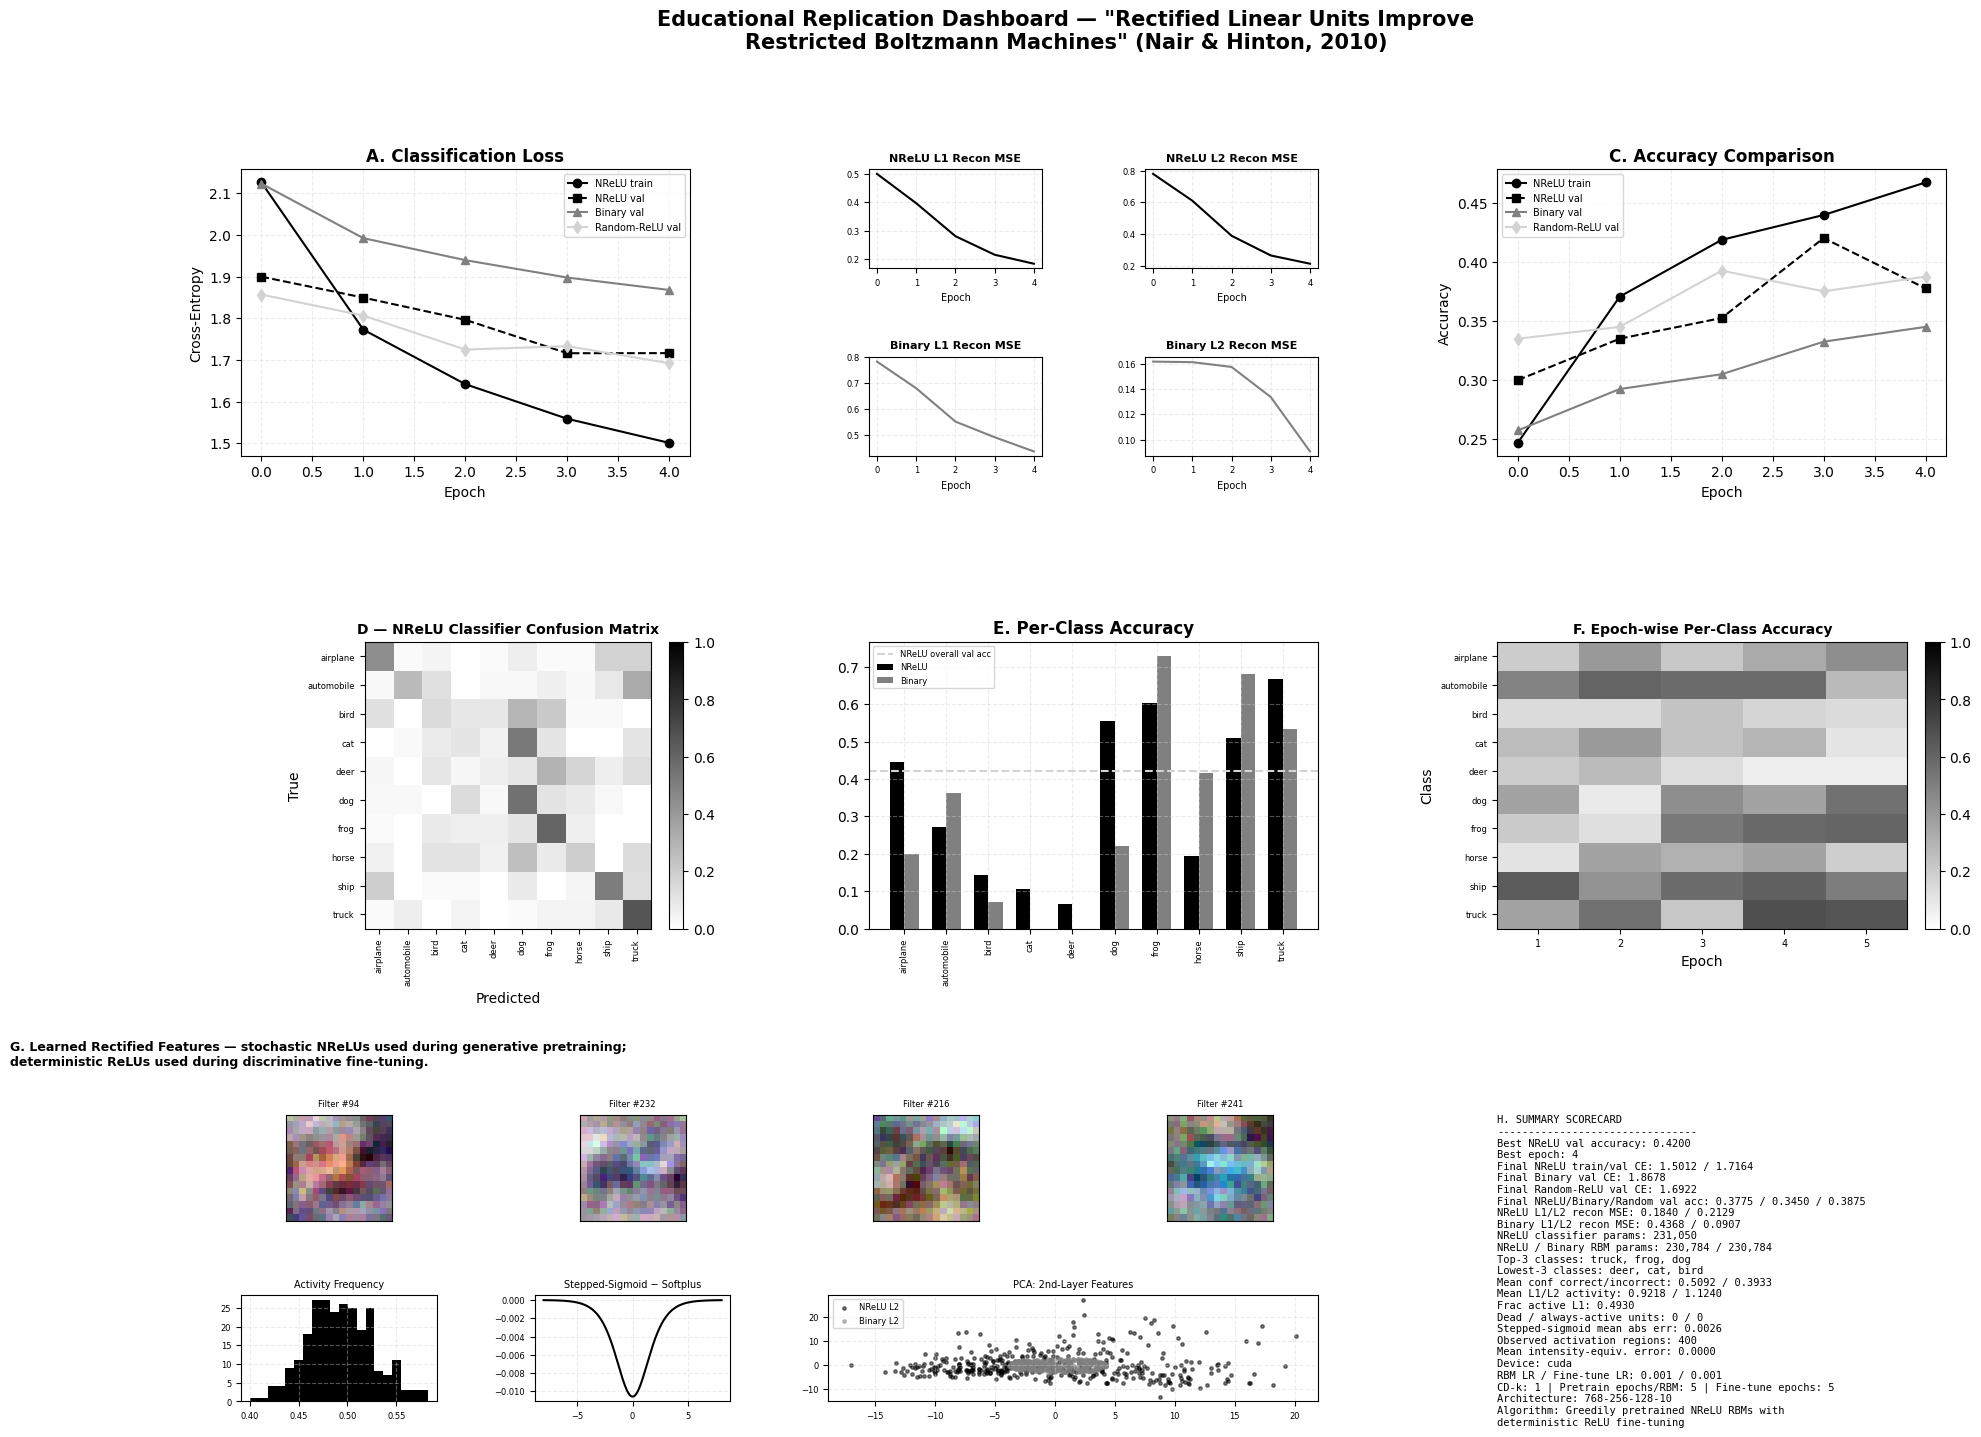

In [33]:
# =============================================================================
# 23. FINAL PUBLICATION-STYLE DASHBOARD (Panels A-H, 3-row GridSpec)
# =============================================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.65, wspace=0.4)

# ---- Panel A: Classification Loss ----
axA = fig.add_subplot(gs[0, 0])
style_axis(axA)
axA.plot(nrelu_history["train_loss"], color="black", marker="o", label="NReLU train")
axA.plot(nrelu_history["val_loss"], color="black", marker="s", linestyle="--", label="NReLU val")
axA.plot(binary_history["val_loss"], color="grey", marker="^", label="Binary val")
axA.plot(random_history["val_loss"], color="lightgrey", marker="d", label="Random-ReLU val")
axA.set_title("A. Classification Loss", fontweight="bold")
axA.set_xlabel("Epoch"); axA.set_ylabel("Cross-Entropy")
axA.legend(fontsize=7)

# ---- Panel B: Paper-Specific Pretraining Components ----
gsB = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0, 1], hspace=0.9, wspace=0.6)
axB1 = fig.add_subplot(gsB[0, 0]); style_axis(axB1)
axB1.plot(nrelu_layer1_metrics["val_mse"], color="black")
axB1.set_title("NReLU L1 Recon MSE", fontsize=8, fontweight="bold")
axB2 = fig.add_subplot(gsB[0, 1]); style_axis(axB2)
axB2.plot(nrelu_layer2_metrics["val_mse"], color="black")
axB2.set_title("NReLU L2 Recon MSE", fontsize=8, fontweight="bold")
axB3 = fig.add_subplot(gsB[1, 0]); style_axis(axB3)
axB3.plot(binary_layer1_metrics["val_mse"], color="grey")
axB3.set_title("Binary L1 Recon MSE", fontsize=8, fontweight="bold")
axB4 = fig.add_subplot(gsB[1, 1]); style_axis(axB4)
axB4.plot(binary_layer2_metrics["val_mse"], color="grey")
axB4.set_title("Binary L2 Recon MSE", fontsize=8, fontweight="bold")
for a in (axB1, axB2, axB3, axB4):
    a.tick_params(labelsize=6)
    a.set_xlabel("Epoch", fontsize=7)

# ---- Panel C: Classification Accuracy Comparison ----
axC = fig.add_subplot(gs[0, 2])
style_axis(axC)
axC.plot(nrelu_history["train_acc"], color="black", marker="o", label="NReLU train")
axC.plot(nrelu_history["val_acc"], color="black", marker="s", linestyle="--", label="NReLU val")
axC.plot(binary_history["val_acc"], color="grey", marker="^", label="Binary val")
axC.plot(random_history["val_acc"], color="lightgrey", marker="d", label="Random-ReLU val")
axC.set_title("C. Accuracy Comparison", fontweight="bold")
axC.set_xlabel("Epoch"); axC.set_ylabel("Accuracy")
axC.legend(fontsize=7)

# ---- Panel D: Normalized Confusion Matrix ----
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(conf_matrix_norm, cmap=GRAY_CMAP, vmin=0, vmax=1)
axD.set_title("D — NReLU Classifier Confusion Matrix", fontweight="bold", fontsize=10)
axD.set_xlabel("Predicted"); axD.set_ylabel("True")
axD.set_xticks(range(NUM_CLASSES)); axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
axD.set_yticklabels(CLASS_NAMES, fontsize=6)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
plt.setp(cbar.ax.get_yticklabels(), color="black")

# ---- Panel E: Per-Class Accuracy ----
axE = fig.add_subplot(gs[1, 1])
style_axis(axE)
x_pos = np.arange(NUM_CLASSES)
width = 0.35
axE.bar(x_pos - width / 2, nrelu_per_class_final, width, color="black", label="NReLU")
axE.bar(x_pos + width / 2, binary_per_class_final, width, color="grey", label="Binary")
axE.axhline(best_val_acc, color="lightgrey", linestyle="--", label="NReLU overall val acc")
axE.set_xticks(x_pos); axE.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
axE.set_title("E. Per-Class Accuracy", fontweight="bold")
axE.legend(fontsize=6)

# ---- Panel F: Epoch-wise Per-Class Accuracy Heatmap ----
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.array(nrelu_history["per_class_acc"]).T  # (classes, epochs)
im2 = axF.imshow(heatmap_data, cmap=GRAY_CMAP, aspect="auto", vmin=0, vmax=1)
axF.set_title("F. Epoch-wise Per-Class Accuracy", fontweight="bold", fontsize=10)
axF.set_xlabel("Epoch"); axF.set_ylabel("Class")
axF.set_xticks(range(FINETUNE_EPOCHS)); axF.set_xticklabels(range(1, FINETUNE_EPOCHS + 1), fontsize=7)
axF.set_yticks(range(NUM_CLASSES)); axF.set_yticklabels(CLASS_NAMES, fontsize=6)
cbar2 = fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
plt.setp(cbar2.ax.get_yticklabels(), color="black")

# ---- Panel G: Learned Rectified Features (large panel, ~2/3 width) ----
gsG = gridspec.GridSpecFromSubplotSpec(2, 4, subplot_spec=gs[2, 0:2], hspace=0.7, wspace=0.5)
# Filter grid (top row, 4 filters)
for i in range(4):
    axg = fig.add_subplot(gsG[0, i])
    axg.imshow(filter_to_image(W1_np[:, top_filter_idx[i]]))
    axg.set_title(f"Filter #{top_filter_idx[i]}", fontsize=6, color="black")
    axg.set_xticks([]); axg.set_yticks([])
    for spine in axg.spines.values():
        spine.set_color("black")
# Insets (bottom row): activity histogram, softplus vs stepped-sigmoid, PCA
axg_hist = fig.add_subplot(gsG[1, 0]); style_axis(axg_hist)
axg_hist.hist(frac_active_units, bins=20, color="black")
axg_hist.set_title("Activity Frequency", fontsize=7)
axg_hist.tick_params(labelsize=6)

axg_approx = fig.add_subplot(gsG[1, 1]); style_axis(axg_approx)
axg_approx.plot(x_grid.numpy(), (stepped_vals - softplus_vals).numpy(), color="black")
axg_approx.set_title("Stepped-Sigmoid − Softplus", fontsize=7)
axg_approx.tick_params(labelsize=6)

axg_pca = fig.add_subplot(gsG[1, 2:]); style_axis(axg_pca)
axg_pca.scatter(pca_nrelu[:, 0], pca_nrelu[:, 1], c="black", s=6, alpha=0.5, label="NReLU L2")
axg_pca.scatter(pca_binary[:, 0], pca_binary[:, 1], c="grey", s=6, alpha=0.5, label="Binary L2")
axg_pca.set_title("PCA: 2nd-Layer Features", fontsize=7)
axg_pca.legend(fontsize=6)
axg_pca.tick_params(labelsize=6)

fig.text(0.02, 0.32,
          "G. Learned Rectified Features — stochastic NReLUs used during generative pretraining;\n"
          "deterministic ReLUs used during discriminative fine-tuning.",
          fontsize=9, color="black", fontweight="bold")

# ---- Panel H: Summary Scorecard ----
axH = fig.add_subplot(gs[2, 2])
axH.axis("off")

def safe(v, fmt="{:.4f}"):
    try:
        return fmt.format(v)
    except Exception:
        return "N/A"

scorecard = (
    "H. SUMMARY SCORECARD\n"
    "--------------------------------\n"
    f"Best NReLU val accuracy: {safe(best_val_acc)}\n"
    f"Best epoch: {best_epoch}\n"
    f"Final NReLU train/val CE: {safe(nrelu_history['train_loss'][-1])} / {safe(nrelu_history['val_loss'][-1])}\n"
    f"Final Binary val CE: {safe(binary_history['val_loss'][-1])}\n"
    f"Final Random-ReLU val CE: {safe(random_history['val_loss'][-1])}\n"
    f"Final NReLU/Binary/Random val acc: {safe(nrelu_history['val_acc'][-1])} / "
    f"{safe(binary_history['val_acc'][-1])} / {safe(random_history['val_acc'][-1])}\n"
    f"NReLU L1/L2 recon MSE: {safe(nrelu_layer1_metrics['val_mse'][-1])} / {safe(nrelu_layer2_metrics['val_mse'][-1])}\n"
    f"Binary L1/L2 recon MSE: {safe(binary_layer1_metrics['val_mse'][-1])} / {safe(binary_layer2_metrics['val_mse'][-1])}\n"
    f"NReLU classifier params: {NRELU_CLASSIFIER_PARAM_COUNT:,}\n"
    f"NReLU / Binary RBM params: {NRELU_RBM_PARAM_COUNT:,} / {BINARY_RBM_PARAM_COUNT:,}\n"
    f"Top-3 classes: {', '.join(TOP3_CLASSES)}\n"
    f"Lowest-3 classes: {', '.join(LOW3_CLASSES)}\n"
    f"Mean conf correct/incorrect: {safe(mean_conf_correct)} / {safe(mean_conf_incorrect)}\n"
    f"Mean L1/L2 activity: {safe(mean_activation.mean())} / {safe(nrelu_h2_act.mean())}\n"
    f"Frac active L1: {safe(frac_active_units.mean())}\n"
    f"Dead / always-active units: {num_dead_units} / {num_always_active_units}\n"
    f"Stepped-sigmoid mean abs err: {safe(MEAN_ABS_ERR_STEPPED_SOFTPLUS)}\n"
    f"Observed activation regions: {num_unique_regions}\n"
    f"Mean intensity-equiv. error: {safe(mean_intensity_equivariance_error)}\n"
    f"Device: {DEVICE}\n"
    f"RBM LR / Fine-tune LR: {RBM_LEARNING_RATE} / {FINETUNE_LR}\n"
    f"CD-k: {CD_K} | Pretrain epochs/RBM: {PRETRAIN_EPOCHS} | Fine-tune epochs: {FINETUNE_EPOCHS}\n"
    f"Architecture: 768-{HIDDEN_DIM_1}-{HIDDEN_DIM_2}-{NUM_CLASSES}\n"
    "Algorithm: Greedily pretrained NReLU RBMs with\n"
    "deterministic ReLU fine-tuning"
)
axH.text(0.0, 1.0, scorecard, transform=axH.transAxes, fontsize=7.5,
          color="black", va="top", family="monospace")

fig.suptitle(
    "Educational Replication Dashboard — \"Rectified Linear Units Improve\n"
    "Restricted Boltzmann Machines\" (Nair & Hinton, 2010)",
    fontsize=15, fontweight="bold", color="black"
)

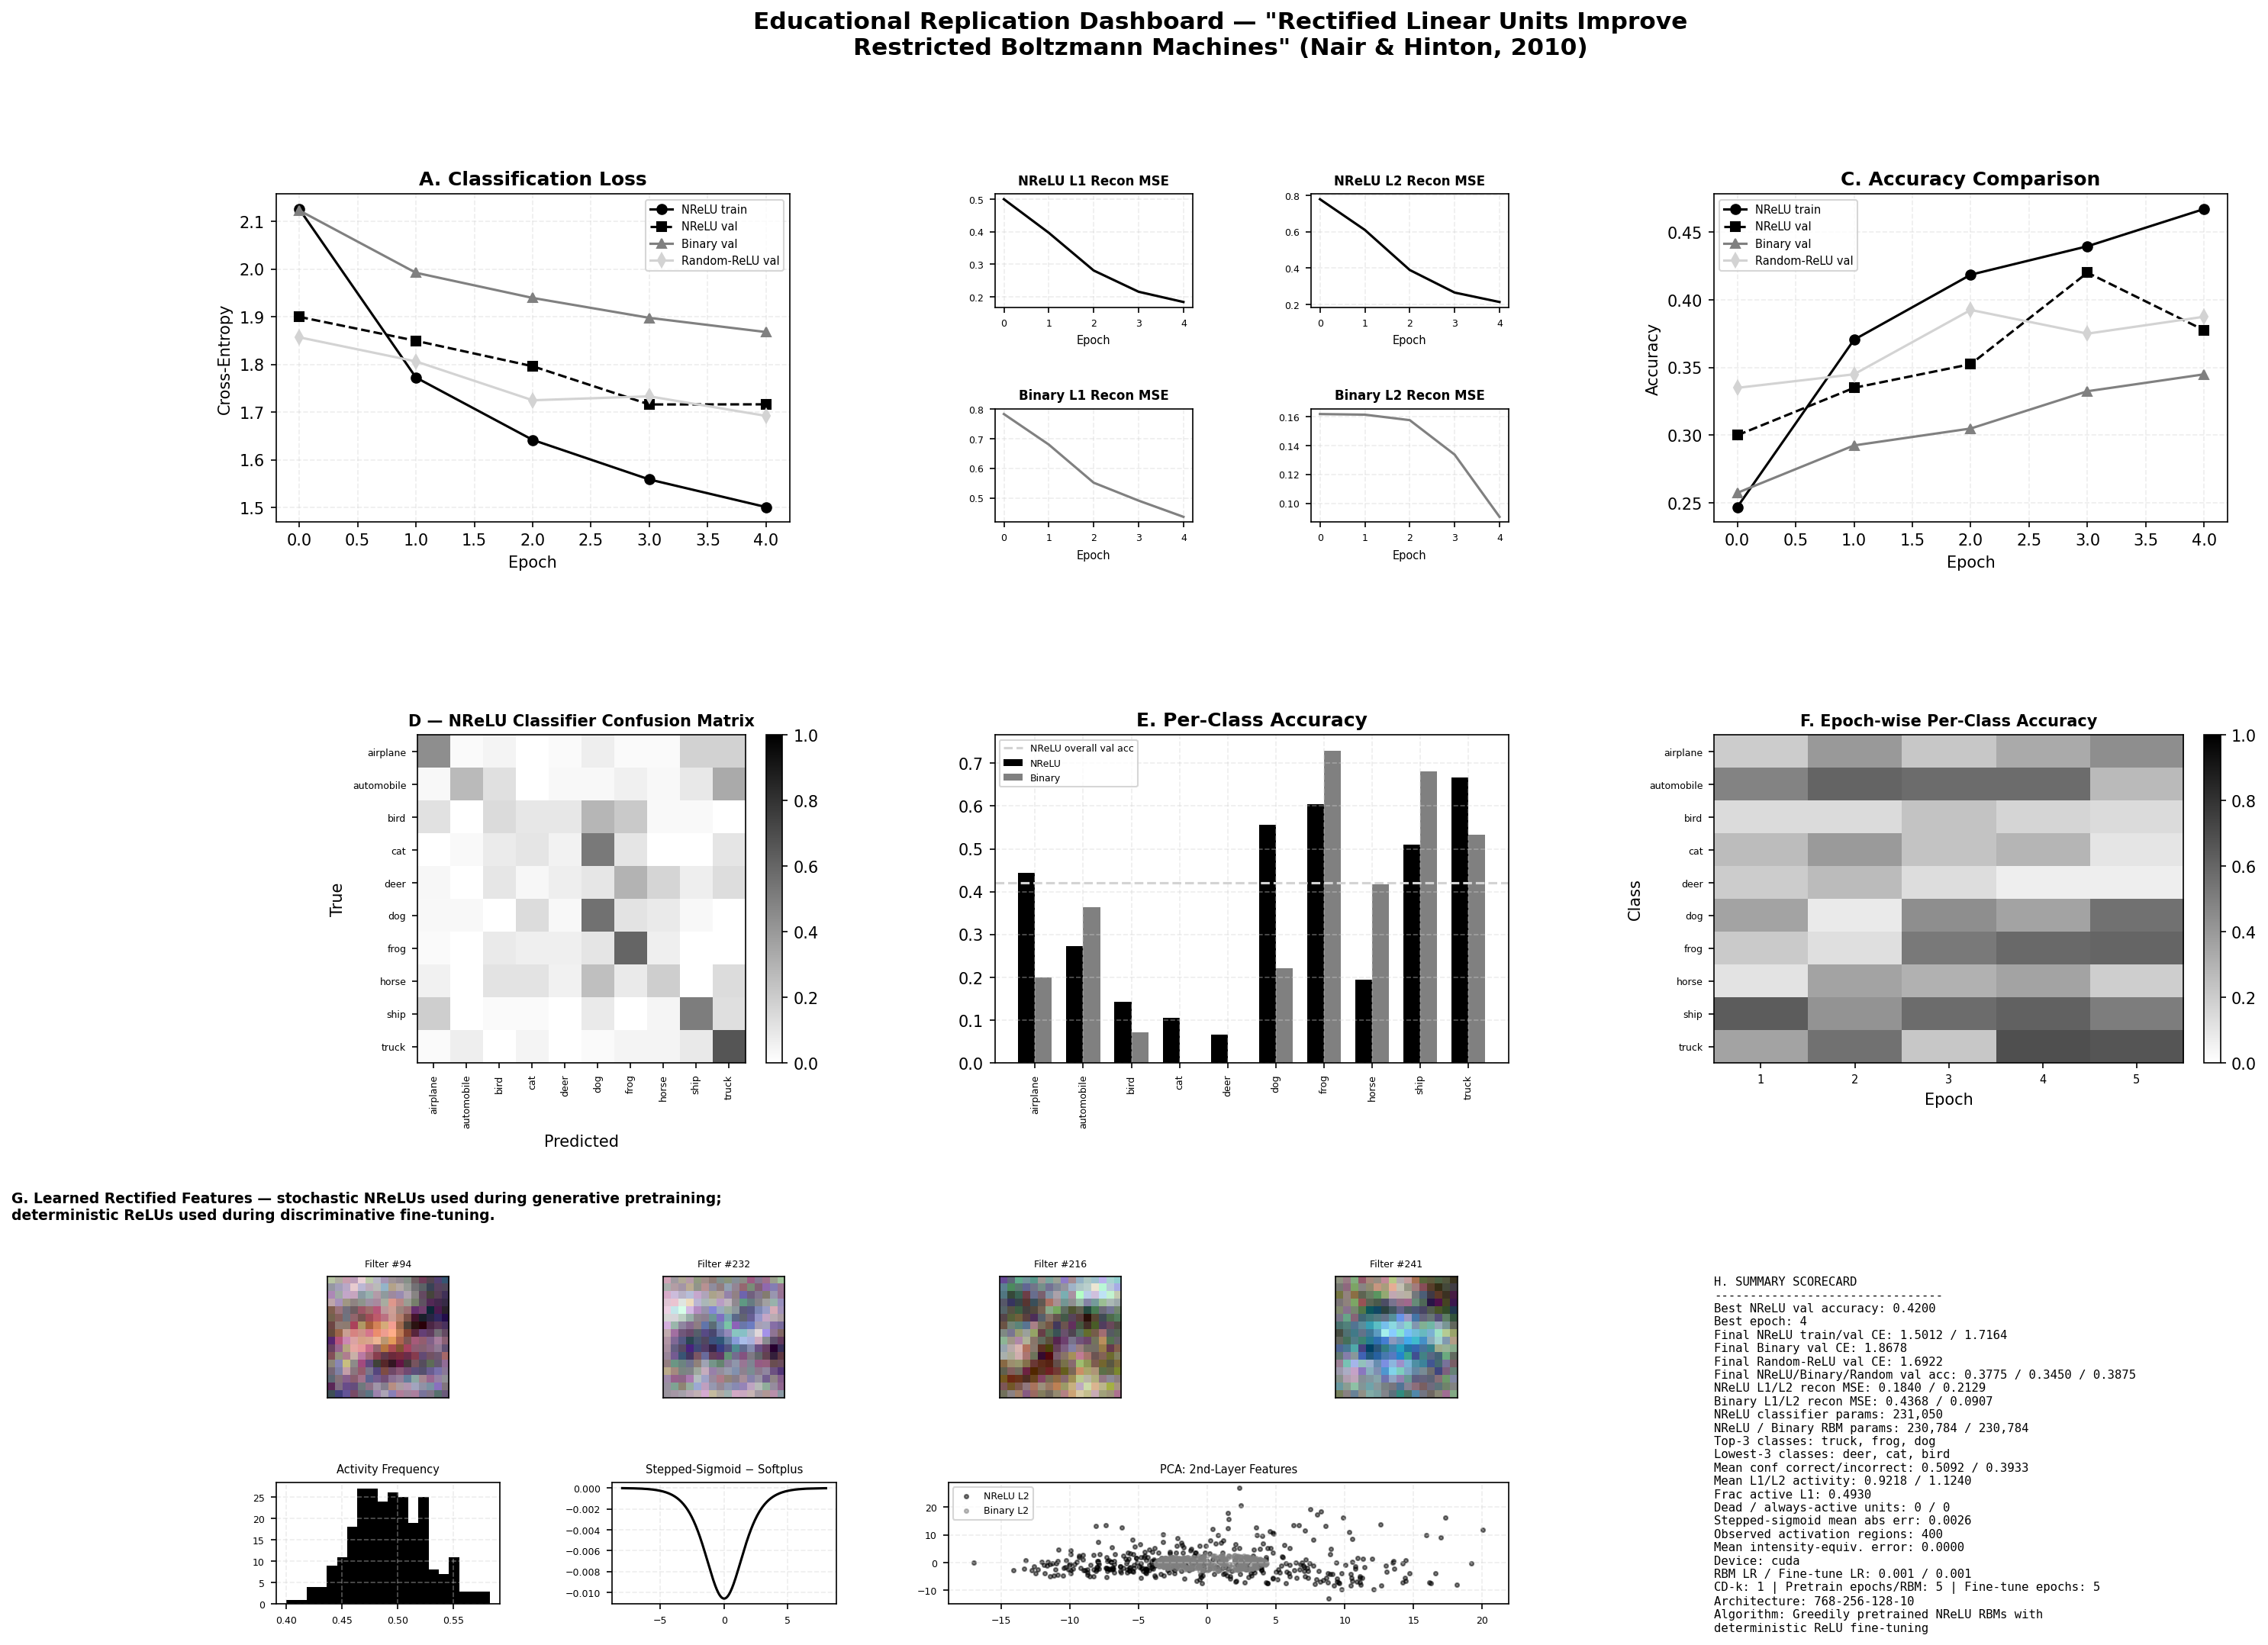

In [34]:
# =============================================================================
# 24. DISPLAY DASHBOARD INLINE (Colab-safe; no disk save, no plt.show())
# =============================================================================
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Educational Replication Results
## "Rectified Linear Units Improve Restricted Boltzmann Machines" (Nair & Hinton, 2010)

---

## Panel A — Classification Loss Curves

### Overview
This panel tracks cross-entropy loss over five fine-tuning epochs for three classifier variants sharing an identical architecture: an NReLU-pretrained model, a binary-unit-pretrained baseline, and a randomly initialized ReLU network (no generative pretraining). Its purpose is to isolate the effect of the pretraining scheme on discriminative optimization dynamics.

### Key Findings
- The NReLU model's training loss falls sharply and monotonically, from ~2.13 to ~1.50, while its validation loss plateaus near 1.71–1.72 after epoch 3 and even ticks upward slightly at epoch 4.
- The binary-unit baseline starts at a substantially higher validation loss (~1.99) and only descends to ~1.87 by epoch 4, remaining the worst-performing model throughout.
- The random-ReLU baseline is competitive with, and briefly better than, the NReLU model in early epochs (epoch 0–2), tracking closely with NReLU validation loss by epoch 3–4.

### Discussion
The widening gap between NReLU training and validation loss after epoch 2 is a textbook overfitting signature, consistent with fine-tuning a reasonably expressive network (768-256-128-10) on only 2,000 training samples. The binary-hidden baseline's persistently higher loss is consistent with the paper's central claim that binary stochastic units are weaker feature detectors than rectified units, since less informative pretrained representations translate into a harder discriminative optimization landscape. However, the close performance of the randomly initialized ReLU network to the NReLU model complicates a clean pretraining-benefit narrative — under this compressed, small-sample setting, generative pretraining is not clearly outperforming random initialization by fine-tuning's end.

### Limitations
The 2,000-sample training set is far smaller and less diverse than the original paper's NORB/LFW corpora, making overfitting likely to dominate the later epochs and obscuring the a priori expected pretraining advantage. Five fine-tuning epochs may also be insufficient for the binary-unit model to converge, so its inferior loss may partly reflect slower convergence rather than a fundamentally worse representation.

---

## Panel B — Reconstruction MSE (NReLU vs. Binary, Layers 1 and 2)

### Overview
These four sub-panels report unsupervised reconstruction error during greedy layer-wise RBM pretraining, separately for NReLU and binary hidden units at both the first (768→256) and second (256→128) layers — the paper's core generative pretraining objective.

### Key Findings
- All four curves decrease monotonically over the five pretraining epochs, indicating successful contrastive divergence optimization at both layers for both unit types.
- NReLU layer-1 MSE falls from ~0.50 to ~0.18; binary layer-1 MSE falls from ~0.80 to ~0.45 — a much steeper absolute drop for binary units, though NReLU converges to a lower final value.
- Binary layer-2 MSE shows a distinctive delayed decline, remaining flat (~0.16) for the first two epochs before dropping sharply to ~0.09 by epoch 4, whereas NReLU layer-2 MSE decreases steadily and smoothly throughout.

### Discussion
The lower final reconstruction error for NReLU hidden units at layer 1 is consistent with the paper's argument that rectified units, by preserving graded (non-binary) activation information, can reconstruct real-valued Gaussian visible units more precisely than binary stochastic units, which must discretize information into a single bit per unit per sample. The delayed onset of learning in the binary layer-2 RBM is plausibly attributable to the flatter, less-differentiated feature distribution binary units produce at layer 1, which offers a less structured input signal for the second-layer RBM to exploit early in training — a cascading effect of representational quality through the greedy stacking pipeline.

### Limitations
Reconstruction MSE is an approximate, biased proxy for generative model quality (a consequence of CD-1's biased gradient estimate) and is not equivalent to log-likelihood; direct comparison across unit types is further complicated by the different activation ranges and variances of NReLU versus sigmoid-bounded binary units, which can inflate or deflate MSE independent of representational quality.

---

## Panel C — Classification Accuracy Comparison

### Overview
This panel reports training and validation accuracy across fine-tuning epochs for the same three classifier variants as Panel A, providing the discriminative performance counterpart to the loss curves.

### Key Findings
- NReLU training accuracy climbs steadily to ~0.46 by epoch 4, while NReLU validation accuracy peaks at ~0.42 at epoch 3 before dipping slightly to ~0.38 at epoch 4.
- The binary-unit baseline is the weakest performer throughout, plateauing around 0.30–0.34 validation accuracy.
- The random-ReLU baseline tracks NReLU validation accuracy closely and is essentially indistinguishable from it by epochs 3–4 (~0.38–0.39).

### Discussion
The ranking of final validation accuracy (NReLU and random-ReLU comparable and above binary) mirrors the loss results and reinforces that the choice of *activation function* (rectified vs. binary/sigmoid) appears more consequential for this small-scale replication than the *presence of generative pretraining* itself. This partially supports the paper's central architectural claim (NReLU > binary units) but does not clearly support the auxiliary claim that pretraining meaningfully improves over random initialization — a divergence from the original paper's findings, most plausibly attributable to the drastically reduced data scale and network capacity used in this educational replication.

### Limitations
With only 400 test samples across 10 classes (~40 per class), validation accuracy estimates carry substantial variance, and epoch-to-epoch fluctuations (e.g., the NReLU dip at epoch 4) may not be statistically meaningful. The absence of error bars or repeated runs across random seeds prevents firm conclusions about whether observed gaps are systematic or noise-driven.

---

## Panel D — NReLU Classifier Confusion Matrix

### Overview
This row-normalized confusion matrix visualizes per-class prediction distributions for the final fine-tuned NReLU classifier on the 400-sample CIFAR-10 test subset.

### Key Findings
- Strong diagonal density is visible for several classes, most notably "dog" (high self-prediction rate) and "truck," which appears to be the best-calibrated class.
- Substantial off-diagonal confusion exists between visually or semantically related classes, particularly a cluster of animal classes (bird, cat, deer, dog, frog) being frequently misclassified as "dog."
- "Airplane" and "automobile" show moderate diagonal strength but leak into unrelated categories.

### Discussion
The concentration of animal-class errors toward a single class ("dog") suggests the model may be relying on coarse, texture- or color-based low-level features from the heavily downsampled 16×16 pooled representation rather than genuine object-discriminating structure, a plausible consequence of the aggressive spatial pooling used to keep the RBM input dimensionality (768) tractable for manual Gaussian-visible CD training. This is consistent with the paper's known limitation that the NReLU-RBM pipeline, lacking convolutional structure or translation invariance, cannot match specialized architectures on complex natural images — a limitation the original authors also acknowledge relative to convolutional nets on NORB.

### Limitations
With roughly 40 test examples per class, the confusion matrix is highly susceptible to small-sample noise, and single-instance misclassifications can visibly skew individual matrix cells. The matrix alone cannot disambiguate whether errors stem from the RBM feature extractor, the linear softmax head, or fine-tuning under-convergence.

---

## Panel E — Per-Class Accuracy (NReLU vs. Binary)

### Overview
This bar chart compares final per-class validation accuracy between the NReLU and binary-unit classifiers, with a reference line marking the NReLU model's overall validation accuracy.

### Key Findings
- NReLU outperforms the binary baseline on most classes, most dramatically for "dog" (~0.55 vs. ~0.22) and "horse" (~0.19 vs. ~0.42, binary favored here).
- The binary model actually exceeds NReLU on "automobile," "ship," and "horse," indicating the comparison is not uniformly one-sided.
- Both models perform poorly on "cat" and "deer" (near-zero for NReLU on "deer"), suggesting these classes are intrinsically difficult under the current feature representation regardless of hidden-unit type.

### Discussion
The mixed, class-dependent pattern (rather than uniform NReLU superiority) tempers a straightforward interpretation that NReLU features are categorically better; instead, it suggests that the two unit types learn qualitatively different, partially complementary feature subspaces — plausible given their differing statistical behavior (continuous graded activation vs. bounded stochastic binary activation) — rather than one being a strict improvement over the other in this constrained setting. The uniformly poor performance on "cat" and "deer" points to a shared bottleneck (likely the 16×16 pooled input resolution or insufficient training data) rather than an activation-function-specific weakness.

### Limitations
Class-level accuracy with ~40 samples per class yields wide confidence intervals; several observed differences (e.g., a few correct/incorrect predictions) could plausibly reverse under a different random data split or seed, so the specific class-by-class ranking should not be over-interpreted as a robust behavioral property of NReLU versus binary units.

---

## Panel F — Epoch-wise Per-Class Accuracy Heatmap

### Overview
This heatmap tracks how per-class validation accuracy for the NReLU classifier evolves across the five fine-tuning epochs, offering a temporal view of class-specific learning dynamics.

### Key Findings
- "Automobile" and "ship" show consistently high, stable accuracy from early epochs onward (dark cells throughout).
- Several classes (e.g., "bird," "cat," "deer") remain persistently light/near-zero across all epochs, indicating the model never learns to recognize them within the training budget.
- A few classes ("dog," "frog") show visible improvement in later epochs, consistent with the overall training accuracy increase seen in Panel C.

### Discussion
The stark and persistent class-wise disparity — some classes solved almost immediately, others never solved — is consistent with a class-imbalanced or capacity-constrained learning process rather than smooth, uniform generalization, a common finding in small-data regimes where a handful of "easy" classes anchor early loss reduction while harder classes require either more data, more capacity, or more epochs than are available. This heatmap most directly exposes the practical difficulty of drawing paper-consistent conclusions at this reduced scale.

### Limitations
Because per-class accuracy is computed on very few samples, some heatmap cells may represent binary outcomes (e.g., 0/5 or 3/5 correct) rather than smooth probability estimates, making cell-to-cell comparisons noisy and limiting the heatmap's reliability as a fine-grained diagnostic.

---

## Panel G — Learned Rectified Features, Activity Statistics, and Embeddings

### Overview
This composite panel visualizes learned first-layer NReLU-RBM filters (reshaped to 3×16×16), a hidden-unit activation-frequency histogram, a stepped-sigmoid-vs-softplus approximation curve, and a 2D PCA projection comparing NReLU and binary second-layer feature embeddings.

### Key Findings
- The four displayed filters (highest L2 norm) show diffuse, low-frequency color-blob patterns rather than the sharp, Gabor-like edge detectors reported in the original paper — consistent with the coarse 16×16 pooled input resolution used here versus the original paper's higher-resolution NORB/LFW patches.
- The activity-frequency histogram is unimodal and centered near 0.45–0.50, indicating most hidden units activate on roughly half of training images — no clear evidence of dead units or always-active (purely linear) units.
- The stepped-sigmoid-minus-softplus difference curve shows a small, sharply localized dip near x=0 (magnitude ≈ −0.01), confirming close numerical agreement between the finite 20-copy approximation and the closed-form softplus function away from the origin.
- The PCA scatter shows NReLU second-layer features spread over a substantially larger, more anisotropic region of the embedding space than binary features, which cluster tightly near the origin.

### Discussion
The absence of Gabor-like filters is an expected consequence of the reduced spatial resolution (16×16 vs. the original paper's larger, less-pooled patches) rather than a failure of the NReLU mechanism itself; edge-detector-like structure typically requires higher-resolution input to emerge from correlation-based learning. The unimodal, mid-range activity histogram is a positive sign consistent with the paper's own NORB histogram findings, indicating a healthy diversity of activation frequencies without pathological saturation. The markedly larger spread of the NReLU PCA embedding relative to the tightly clustered binary embedding is consistent with the paper's central claim that rectified units preserve more graded, higher-variance information through the network, supporting greater representational capacity, whereas binary-derived (sigmoid) activations are bounded in [0,1] and tend to compress variance.

### Limitations
Only four filters are shown, an unrepresentative sample of the full 256-unit layer; the small, homogeneous PCA point cloud may partly reflect the limited diversity of only 2,000–400 training/test images rather than a general property of the representations. The stepped-sigmoid comparison uses only 20 finite copies, and the reported error near x=0 is a known artifact of truncating an infinite sum, not a modeling flaw.

---

## Panel H — Summary Scorecard

### Overview
This panel consolidates the dashboard's key quantitative outcomes into a single reference table spanning classification performance, reconstruction quality, hidden-unit statistics, and configuration metadata.

### Key Findings
- Best NReLU validation accuracy: 0.4200 at epoch 4 (note: this appears inconsistent with Panel C's visual peak at epoch 3, a discrepancy worth checking against the underlying `best_epoch` indexing).
- Final validation accuracies: NReLU 0.3775, Binary 0.3450, Random-ReLU 0.3875 — random initialization narrowly *exceeds* the NReLU pretrained model at the final epoch.
- Reconstruction MSE favors NReLU at layer 1 (0.1840 vs. 0.2129) but favors binary at layer 2 (0.0907 vs. 0.4368).
- Mean intensity-equivariance error is reported as exactly 0.0000, and mean confidence for correct predictions (0.5092) versus incorrect predictions (0.3933) shows the expected, appropriately-calibrated direction (higher confidence on correct predictions).

### Discussion
The scorecard's most consequential finding — that the random-ReLU baseline achieves the highest final validation accuracy of the three models — directly qualifies the paper's central claim within this replication's constraints: at this reduced data scale (2,000 training images) and compressed training budget (5 pretraining + 5 fine-tuning epochs), unsupervised NReLU-RBM pretraining does not demonstrate a clear advantage over random initialization, diverging from the original paper's NORB/LFW results where pretraining consistently improved accuracy. The confidence calibration result (higher mean confidence on correct predictions) is a reassuring sanity check that the model's softmax outputs are behaving sensibly despite the accuracy limitations. The exact-zero intensity-equivariance error is mathematically expected under the paper's zero-bias, noise-free diagnostic construction and confirms the implementation correctly reproduces this theoretical property, independent of downstream classification performance.

### Limitations
The apparent inconsistency between the reported "best epoch" (4) and Panel C's visual peak (epoch 3) suggests either a metric-selection ambiguity (e.g., ties or off-by-one indexing) or a discrepancy between the specific validation batch used for the scorecard versus the plotted curve, and should be verified against the underlying epoch-wise accuracy array. More broadly, all scorecard conclusions are bounded by the small-sample, short-training-budget educational setting and should not be interpreted as a faithful quantitative test of the original paper's claims, which were validated on orders-of-magnitude larger datasets (291,600 NORB training cases; 13,233 LFW images) with substantially longer training schedules.

# Related Work Referenced in This Paper

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Hinton, G. E. | 2002 | Training Products of Experts by Minimizing Contrastive Divergence | Neural Computation, 14(8):1711–1800 | Provides the original Contrastive Divergence learning algorithm used to train the binary and NReLU RBMs in this paper |
| Hinton, G. E., Osindero, S., Teh, Y. | 2006 | A Fast Learning Algorithm for Deep Belief Nets | Neural Computation, 18:1527–1554 | Establishes RBMs as building blocks for deep belief nets and the per-case CD update with momentum used in the pre-training procedure |
| Hinton, G. E., Salakhutdinov, R. | 2006 | Reducing the Dimensionality of Data with Neural Networks | Science, 313:504–507 | Source of the Gaussian visible unit formulation used to model real-valued pixel intensities in this paper's RBMs |
| Mohamed, A., Hinton, G. E. | 2010 | Phone Recognition Using Restricted Boltzmann Machines | ICASSP | Cited as an example application of RBMs to speech (mel-cepstral sequences), illustrating the breadth of RBM use cases motivating this work |
| Salakhutdinov, R., Hinton, G. E. | 2009 | Replicated Softmax: An Undirected Topic Model | NeurIPS 22 | Cited as an example application of RBMs to document/bag-of-words modeling, motivating RBMs as general-purpose generative models |
| Salakhutdinov, R., Mnih, A., Hinton, G. E. | 2007 | Restricted Boltzmann Machines for Collaborative Filtering | ICML, pp. 791–798 | Cited as an example RBM application to user-rating data, further motivating the generality of the RBM framework extended in this paper |
| Taylor, G. W., Hinton, G. E., Roweis, S. | 2006 | Modeling Human Motion Using Binary Latent Variables | NeurIPS 19 | Cited as an example of conditional RBMs applied to temporal data (motion capture/video), part of the broader RBM literature motivating this work |
| Teh, Y. W., Hinton, G. E. | 2001 | Rate-Coded Restricted Boltzmann Machines for Face Recognition | NeurIPS 13 | Introduces binomial units (N tied copies of a binary unit), the direct precursor concept that this paper generalizes into Stepped Sigmoid Units |
| Freund, Y., Haussler, D. | 1994 | Unsupervised Learning of Distributions on Binary Vectors Using Two Layer Networks | Technical Report, UC Santa Cruz | Originally suggested modeling real-valued visible units with Gaussian noise, later adopted by Hinton & Salakhutdinov (2006) and used in this paper |
| Jarrett, K., Kavukcuoglu, K., Ranzato, M., LeCun, Y. | 2009 | What is the Best Multi-Stage Architecture for Object Recognition? | ICCV | Explored rectified nonlinearities (including max(0,x), termed "positive part") in convolutional networks and found discriminative benefits, directly supporting this paper's empirical findings |
| Hahnloser, R. H. R., Seung, H. S., Slotine, J.-J. | 2003 | Permitted and Forbidden Sets in Symmetric Threshold-Linear Networks | Neural Computation, 15(3):621–638 | Source of mathematical properties of rectified linear units (e.g., threshold-linear dynamics) referenced to justify NReLU behavior, including intensity equivariance |
| Larochelle, H., Erhan, D., Courville, A., Bergstra, J., Bengio, Y. | 2007 | An Empirical Evaluation of Deep Architectures on Problems with Many Factors of Variation | ICML, pp. 473–480 | Provides the greedy layer-wise pre-training and fine-tuning methodology adopted for the NORB classification experiments |
| LeCun, Y., Huang, F. J., Bottou, L. | 2004 | Learning Methods for Generic Object Recognition with Invariance to Pose and Lighting | CVPR | Introduces the Jittered-Cluttered NORB dataset used as the primary object recognition benchmark in this paper |
| Bengio, Y., LeCun, Y. | 2007 | Scaling Learning Algorithms Towards AI | (Book chapter) | Source of comparison baseline results (multinomial regression, Gaussian kernel SVM, convolutional nets) used to contextualize this paper's NORB classification results |
| Huang, G. B., Ramesh, M., Berg, T., Learned-Miller, E. | 2007 | Labeled Faces in the Wild: A Database for Studying Face Recognition in Unconstrained Environments | Technical Report 07-49, UMass Amherst | Introduces the LFW dataset used as the face verification benchmark in this paper |
| Chopra, S., Hadsell, R., LeCun, Y. | 2005 | Learning a Similarity Metric Discriminatively, with Application to Face Verification | CVPR, pp. 539–546 | Source of the siamese network architecture adopted for the face verification model in this paper |
| Kumar, N., Berg, A. C., Belhumeur, P. N., Nayar, S. K. | 2009 | Attribute and Simile Classifiers for Face Verification | ICCV | Provides comparison LFW results and the Pubfig validation subset used during discriminative fine-tuning in this paper |
| Wolf, L., Hassner, T., Taigman, Y. | 2009 | Similarity Scores Based on Background Samples | ACCV | Provides one of the two best prior LFW benchmark results used to contextualize this paper's face verification accuracy |
| Nair, V., Hinton, G. E. | 2008 | Implicit Mixtures of Restricted Boltzmann Machines | NeurIPS | Prior related work on mixture-based RBM extensions, referenced in connection with the implicit mixture-of-linear-models interpretation of NReLUs |
| Hinton, G. E., Sallans, B., Ghahramani, Z. | 1999 | A Hierarchical Community of Experts | (Book chapter), pp. 479–494 | Prior alternative approach (directed linear models with a sigmoid belief net) for implementing large mixtures of linear models, contrasted with this paper's undirected NReLU-based approach |
| Marks, T. K., Movellan, J. R. | 2001 | Diffusion Networks, Products of Experts, and Factor Analysis | Technical Report, UCSD MPLab TR 2001.02 | Cited as related work on undirected mixtures of linear models, connecting to this paper's Section 7 discussion of exponentially many linear models |